In [3]:
import sys
sys.path.append("../../../../../pySDC")
import pickle

from pathlib import Path
import numpy as np
import statistics
import pySDC.helpers.plot_helper as plt_helper
from pySDC.implementations.controller_classes.controller_nonMPI import controller_nonMPI
# from pySDC.implementations.controller_classes.controller_MPI import controller_MPI

from pySDC.projects.DAE.problems.ThreeConverterSystem import ThreeConverterSystem
from pySDC.projects.DAE.sweepers.fullyImplicitDAE import FullyImplicitDAE
from pySDC.projects.DAE.sweepers.rungeKuttaDAE import BackwardEulerDAE, TrapezoidalRuleDAE

# from pySDC.projects.DAE.misc.HookClass_DAE import approx_solution_hook
# from pySDC.projects.DAE.misc.HookClass_DAE import error_hook
from pySDC.implementations.hooks.log_solution import LogSolution

from pySDC.helpers.stats_helper import get_sorted
from pySDC.helpers.stats_helper import filter_stats


import time

In [4]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','ieee'])

In [5]:

def single_run(run_name="test", time_step=1e-1, end_time=0.1, sweeper_type = FullyImplicitDAE, useMPI = False, restol=1e-12, newtontol=1e-10):
    """
    A testing ground for the synchronous machine model
    """
    # initialize level parameters
    level_params = dict()
    level_params['restol'] = restol
    level_params['dt'] = time_step

    # initialize sweeper parameters
    M_fix = 3
    sweeper_params = {
        'num_nodes': M_fix,
        'quad_type': 'RADAU-RIGHT',
        'QI': 'IE',
    }

    # initialize problem parameters
    problem_params = dict()
    problem_params['newton_tol'] = newtontol  # tollerance for implicit solver
    problem_params['nvars'] = 36

    # initialize step parameters
    step_params = dict()
    if(sweeper_type == FullyImplicitDAE):
        step_params['maxiter'] = 50
    else:
        step_params['maxiter'] = 1

    # initialize controller parameters
    controller_params = dict()
    controller_params['logger_level'] = 30
    controller_params['hook_class'] = [LogSolution]

    # Fill description dictionary for easy hierarchy creation
    description = dict()
    description['problem_class'] = ThreeConverterSystem
    # description['problem_class'] = WSCC9BusSystem
    description['problem_params'] = problem_params
    description['sweeper_class'] = sweeper_type
    description['sweeper_params'] = sweeper_params
    description['level_params'] = level_params
    description['step_params'] = step_params

    Path("data").mkdir(parents=True, exist_ok=True)

    # instantiate the controller
    
    controller = controller_nonMPI(num_procs=1, controller_params=controller_params, description=description)

    # set time parameters
    t0 = 0.0
    Tend = end_time

    # get initial values on finest level
    P = controller.MS[0].levels[0].prob
    uinit = P.u_exact(t0)

    # call main function to get things done...
    uend, stats = controller.run(u0=uinit, t0=t0, Tend=Tend)


    # store results
    sol = get_sorted(stats, type='approx_solution', sortby='time')
    sol_dt = np.array([sol[i][0] for i in range(len(sol))])
    sol_data = np.array([[sol[j][1][i] for j in range(len(sol))] for i in range(problem_params['nvars'])])
    niter = filter_stats(stats, type='niter')
    niter = np.fromiter(niter.values(), int)

    t = np.array([me[0] for me in get_sorted(stats, type='u', sortby='time')])
    # print([me[1][11*m + 2*m:11*m + 2*m + n] for me in get_sorted(stats, type='approx_solution', sortby='time', recomputed=False)])
    i_c1 = np.array([ me[1][0:2] for me in get_sorted(stats, type='u', sortby='time')])
    i_c2 = np.array([ me[1][8:10] for me in get_sorted(stats, type='u', sortby='time')])
    i_c3 = np.array([ me[1][16:18] for me in get_sorted(stats, type='u', sortby='time')])
    v_cc1 = np.array([ me[1][6:8] for me in get_sorted(stats, type='u', sortby='time')])
    v_cc2 = np.array([ me[1][14:16] for me in get_sorted(stats, type='u', sortby='time')])
    v_cc3 = np.array([ me[1][22:24] for me in get_sorted(stats, type='u', sortby='time')])
    delta1 = np.array([ me[1][5] for me in get_sorted(stats, type='u', sortby='time')])
    delta2 = np.array([ me[1][13] for me in get_sorted(stats, type='u', sortby='time')])
    delta3 = np.array([ me[1][21] for me in get_sorted(stats, type='u', sortby='time')])
    i_pccDQ = np.array([ me[1][24:26] for me in get_sorted(stats, type='u', sortby='time')])
    il_12DQ = np.array([ me[1][26:28] for me in get_sorted(stats, type='u', sortby='time')])
    il_23DQ = np.array([ me[1][28:30] for me in get_sorted(stats, type='u', sortby='time')])
    v_g1DQ = np.array([ me[1][30:32] for me in get_sorted(stats, type='u', sortby='time')])
    v_g2DQ = np.array([ me[1][32:34] for me in get_sorted(stats, type='u', sortby='time')])
    v_g3DQ = np.array([ me[1][34:36] for me in get_sorted(stats, type='u', sortby='time')])

    # i_g1DQ = i_pccDQ - il_12DQ
    # i_g2DQ = il_12DQ - il_23DQ
    # i_g3DQ = il_23DQ

    # i_g1=np.zeros_like(i_g1DQ)
    # i_g2=np.zeros_like(i_g2DQ)
    # i_g3=np.zeros_like(i_g3DQ)

    # for k in range(len(delta1)):
    #     rotation_matrix1 = np.array([[np.cos(delta1[k]), np.sin(delta1[k])], [-np.sin(delta1[k]), np.cos(delta1[k])]])
    #     i_g1[k, :] = np.dot(rotation_matrix1, i_g1DQ[k, :])

    #     rotation_matrix2 = np.array([[np.cos(delta2[k]), np.sin(delta2[k])], [-np.sin(delta2[k]), np.cos(delta2[k])]])
    #     i_g2[k, :] = np.dot(rotation_matrix2, i_g2DQ[k, :])

    #     rotation_matrix3 = np.array([[np.cos(delta3[k]), np.sin(delta3[k])], [-np.sin(delta3[k]), np.cos(delta3[k])]])
    #     i_g3[k, :] = np.dot(rotation_matrix3, i_g3DQ[k, :])

    # fs = 2000
    # Ts = 1/fs
    # Lf = 0.1e-3;    # L Filter
    # Kp  = Lf*1.8/(3*Ts)


    # v_g1 = Kp*(i_c1-i_g1) + v_cc1
    # v_g2 = Kp*(i_c2-i_g2) + v_cc2 
    # v_g3 = Kp*(i_c3-i_g3) + v_cc3 

    # # Initialize i_pcc as a zeros matrix with the same shape as i_pccDQ
    # i_pcc = np.zeros_like(i_pccDQ)

    # # Perform the matrix operations
    # for k in range(len(delta1)):
    #     rotation_matrix = np.array([[np.cos(delta1[k]), np.sin(delta1[k])],
    #                                 [-np.sin(delta1[k]), np.cos(delta1[k])]])
    #     i_pcc[k, :] = np.dot(rotation_matrix, i_pccDQ[k, :])

    # # Set v_pcc to v_g1
    # v_pcc = v_g1

    # # Transpose i_pcc
    # i_pcc = i_pcc.T
    res = {
        "i_c1":i_c1,
        "i_c2":i_c2,
        "i_c3":i_c3,
        "v_cc1":v_cc1,
        "v_cc2":v_cc2,
        "v_cc3":v_cc3,
        "delta1":delta1,
        "delta2":delta2,
        "delta3":delta3,
        "i_pccDQ":i_pccDQ,
        "il_12DQ":il_12DQ,
        "il_23DQ":il_23DQ,
        "v_g1DQ":v_g1DQ,
        "v_g2DQ":v_g2DQ,
        "v_g3DQ":v_g3DQ
        }
    return run_name, t, res # return d-, q-axis 


In [ ]:
# ## run stuff
# # dt_ = 0.01 # 10ms dt
# test_name1, t_1, res_10ms = single_run(f"test_name1", 0.01, 1.2, FullyImplicitDAE)
# test_name2, t_50ms, res_50ms = single_run(f"test_name2", 0.05, 1.2, FullyImplicitDAE)
# test_name4, t_100ms, res_100ms = single_run(f"test_name2", 0.1, 1.2, FullyImplicitDAE)
# test_name5, t_500ms, res_500ms = single_run(f"test_name2", 0.5, 1.5, FullyImplicitDAE)
# np.savetxt("data/ts_sdc_500ms.csv", t_500ms, delimiter=",")
# np.savetxt("data/v_pccDQ_sdc_500ms.csv", res_500ms["v_g1DQ"], delimiter=",")
# pickle.dump(res_500ms, open("data/res_sdc_500ms.p", 'wb'))
# np.savetxt("data/v_pccDQ_sdc_10ms.csv", res_10ms["v_g1DQ"], delimiter=",")
# np.savetxt("data/ts_sdc_10ms.csv", t_1, delimiter=",")
# pickle.dump(res_10ms, open("data/res_sdc_10ms.p", 'wb'))

# np.savetxt("data/v_pccDQ_sdc_50ms.csv", res_50ms["v_g1DQ"], delimiter=",")
# np.savetxt("data/ts_sdc_50ms.csv", t_50ms, delimiter=",")
# pickle.dump(res_50ms, open("data/res_sdc_50ms.p", 'wb'))

# np.savetxt("data/ts_sdc_100ms.csv", t_100ms, delimiter=",")
# np.savetxt("data/v_pccDQ_sdc_100ms.csv", res_100ms["v_g1DQ"], delimiter=",")
# pickle.dump(res_100ms, open("data/res_sdc_100ms.p", 'wb'))
# test_name2, t_1ms,  res_sdc_1ms = single_run(f"test_name1", 1e-3, 1.2, FullyImplicitDAE)
# np.savetxt("data/v_pccDQ_sdc_1ms.csv", res_sdc_1ms["v_g1DQ"], delimiter=",")
# np.savetxt("data/ts_sdc_1ms.csv", t_1ms, delimiter=",")
# pickle.dump(res_sdc_1ms, open("data/res_sdc_1ms.p", 'wb'))


(refactored code)

In [6]:
# import numpy as np

# --- Helper Functions ---
def load_csv(path):
    return np.loadtxt(path, delimiter=',')

def compute_magnitude(arr):
    return np.sqrt(np.sum(arr[:, :2]**2, axis=1))

def shift_time(t, shift):
    return t + shift

def interp_values(t_new, t_old, y):
    return np.interp(t_new, t_old, y)

def filter_data(t, y, t_range):
    mask = (t >= t_range[0]) & (t <= t_range[1])
    return t[mask], y[mask]

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def rel_rmse(y_true, y_pred):
    return rmse(y_true, y_pred) / np.mean(y_true)

# --- Load Data ---
files = {
    'v_sdc_1ms': 'data/v_pccDQ_sdc_1ms_restol_1e-12.csv',
    't_sdc_1ms': 'data/ts_sdc_1ms_restol_1e-12.csv',
    'v_sdc_10ms': 'data/v_pccDQ_sdc_10ms_restol_1e-12.csv',
    't_sdc_10ms': 'data/ts_sdc_10ms_restol_1e-12.csv',
    'v_sdc_50ms': 'data/v_pccDQ_sdc_50ms_restol_1e-12.csv',
    't_sdc_50ms': 'data/ts_sdc_50ms_restol_1e-12.csv',
    'v_sdc_100ms': 'data/v_pccDQ_sdc_100ms_restol_1e-12.csv',
    't_sdc_100ms': 'data/ts_sdc_100ms_restol_1e-12.csv',
    'v_sdc_500ms': 'data/v_pccDQ_sdc_500ms_restol_1e-12.csv',
    't_sdc_500ms': 'data/ts_sdc_500ms_restol_1e-12.csv',
    'v_be_1ms': 'data/threeVSC_octave_res/v_pcc_be_1ms.csv',
    'v_TR_1ms': 'data/threeVSC_octave_res/v_pcc_TR_1ms.csv',
    'v_rk4_100us': 'data/threeVSC_octave_res/v_pcc_rk4_100us.csv',
    't_ode15s': 'data/threeVSC_octave_res/t_ode15s.csv',
    'v_ode15s': 'data/threeVSC_octave_res/v_pcc_ode15s.csv'
}

data = {key: load_csv(path) for key, path in files.items()}

# --- Generate Time Arrays ---
# For "be" (assumed 1ms) and others, 
#   use the number of rows to generate evenly spaced timestamps.
num_be = data['v_be_1ms'].shape[0]
num_rk4 = data['v_rk4_100us'].shape[0]
num_TR = data['v_TR_1ms'].shape[0]

ts_be   = np.linspace(0, 1.2, num=num_be+1)[1:]
ts_rk4  = np.linspace(0, 1.2, num=num_rk4+1)[1:]
ts_TR   = np.linspace(0, 1.5, num=num_TR+1)[1:]

# --- Compute Magnitudes ---
magnitudes = {}
for key in ['v_sdc_1ms', 'v_sdc_10ms', 'v_sdc_50ms', 'v_sdc_100ms', 'v_sdc_500ms', 
            'v_be_1ms', 'v_TR_1ms', 'v_rk4_100us', 'v_ode15s']:
    magnitudes[key] = compute_magnitude(data[key])

# --- Time Shifts and Reference Interpolation ---
t_sdc_1ms = data['t_sdc_1ms']  
t_sdc_10ms = data['t_sdc_10ms']
t_sdc_50ms = data['t_sdc_50ms']
t_sdc_100ms = data['t_sdc_100ms']

t_sdc_1ms_shifted = shift_time(t_sdc_1ms, 1e-3)
t_sdc_10ms_shifted = shift_time(t_sdc_10ms, 10e-3)
t_sdc_50ms_shifted = shift_time(t_sdc_50ms, 50e-3)
t_sdc_100ms_shifted = shift_time(t_sdc_100ms, 100e-3)

# Use ts_rk4 as reference time, and interpolate the ode15s magnitude as reference.
t_ref = ts_rk4
v_ref = interp_values(t_ref, data['t_ode15s'], magnitudes['v_ode15s'])

# Interpolate signals to reference time t_ref
signals = {
    'sdc_1ms_shifted': interp_values(t_ref, t_sdc_1ms_shifted, magnitudes['v_sdc_1ms']),
    'sdc_10ms_shifted': interp_values(t_ref, t_sdc_10ms_shifted, magnitudes['v_sdc_10ms']),
    'sdc_50ms_shifted': interp_values(t_ref, t_sdc_50ms_shifted, magnitudes['v_sdc_50ms']),
    'sdc_100ms_shifted': interp_values(t_ref, t_sdc_100ms_shifted, magnitudes['v_sdc_100ms']),
    'TR_1ms': interp_values(t_ref, ts_TR, magnitudes['v_TR_1ms']),
    'sdc_1ms': interp_values(t_ref, t_sdc_1ms, magnitudes['v_sdc_1ms']),
    'sdc_10ms': interp_values(t_ref, t_sdc_10ms, magnitudes['v_sdc_10ms']),
    'sdc_50ms': interp_values(t_ref, t_sdc_50ms, magnitudes['v_sdc_50ms']),
    'sdc_100ms': interp_values(t_ref, t_sdc_100ms, magnitudes['v_sdc_100ms'])
}

# Compute relative errors for each signal (if needed)
rel_errors = {key: np.abs((sig - v_ref) / v_ref) for key, sig in signals.items()}

# --- Filter Data for Specified Ranges ---
ranges = {'transient': (1.00, 1.05), 'steady': (1.15, 1.20)}
filtered = {}
for phase, rng in ranges.items():
    t_phase, v_phase = filter_data(t_ref, v_ref, rng)
    filtered[phase] = {'t': t_phase, 'v_ref': v_phase}

# Interpolate each signal for the filtered phases
signals_filt = {phase: {} for phase in ranges}
for phase in ranges:
    for key, sig in signals.items():
        signals_filt[phase][key] = interp_values(filtered[phase]['t'], t_ref, sig)

# --- Compute RMSE and Relative RMSE for Each Signal and Phase ---
rmse_results = {phase: {} for phase in ranges}
for phase in ranges:
    for key, sig in signals_filt[phase].items():
        r = rmse(filtered[phase]['v_ref'], sig)
        rr = rel_rmse(filtered[phase]['v_ref'], sig)
        rmse_results[phase][key] = (r, rr)

# --- Print Results ---
print("Transient RMSE and Relative RMSE:")
for key, (r, rr) in rmse_results['transient'].items():
    print(f"{key}: RMSE = {r}, Relative RMSE = {rr}")

print("\nSteady-state RMSE and Relative RMSE:")
for key, (r, rr) in rmse_results['steady'].items():
    print(f"{key}: RMSE = {r}, Relative RMSE = {rr}")


Transient RMSE and Relative RMSE:
sdc_1ms_shifted: RMSE = 0.7429742512106216, Relative RMSE = 0.0014517780878520296
sdc_10ms_shifted: RMSE = 14.165419669743283, Relative RMSE = 0.027679352074788877
sdc_50ms_shifted: RMSE = 18.45618841834584, Relative RMSE = 0.03606355117605164
sdc_100ms_shifted: RMSE = 32.87877190931364, Relative RMSE = 0.06424540357307068
TR_1ms: RMSE = 3.090572517325971, Relative RMSE = 0.006039005325232444
sdc_1ms: RMSE = 3.9753344859211053, Relative RMSE = 0.007767837834405245
sdc_10ms: RMSE = 9.644790164795573, Relative RMSE = 0.018846003075295815
sdc_50ms: RMSE = 7.519359131998265, Relative RMSE = 0.0146928925258683
sdc_100ms: RMSE = 24.846319287087294, Relative RMSE = 0.048549921946814456

Steady-state RMSE and Relative RMSE:
sdc_1ms_shifted: RMSE = 0.0005866883371444576, Relative RMSE = 1.1482251648948434e-06
sdc_10ms_shifted: RMSE = 0.0007511228183301182, Relative RMSE = 1.4700447705014127e-06
sdc_50ms_shifted: RMSE = 0.03309582987749729, Relative RMSE = 6.477

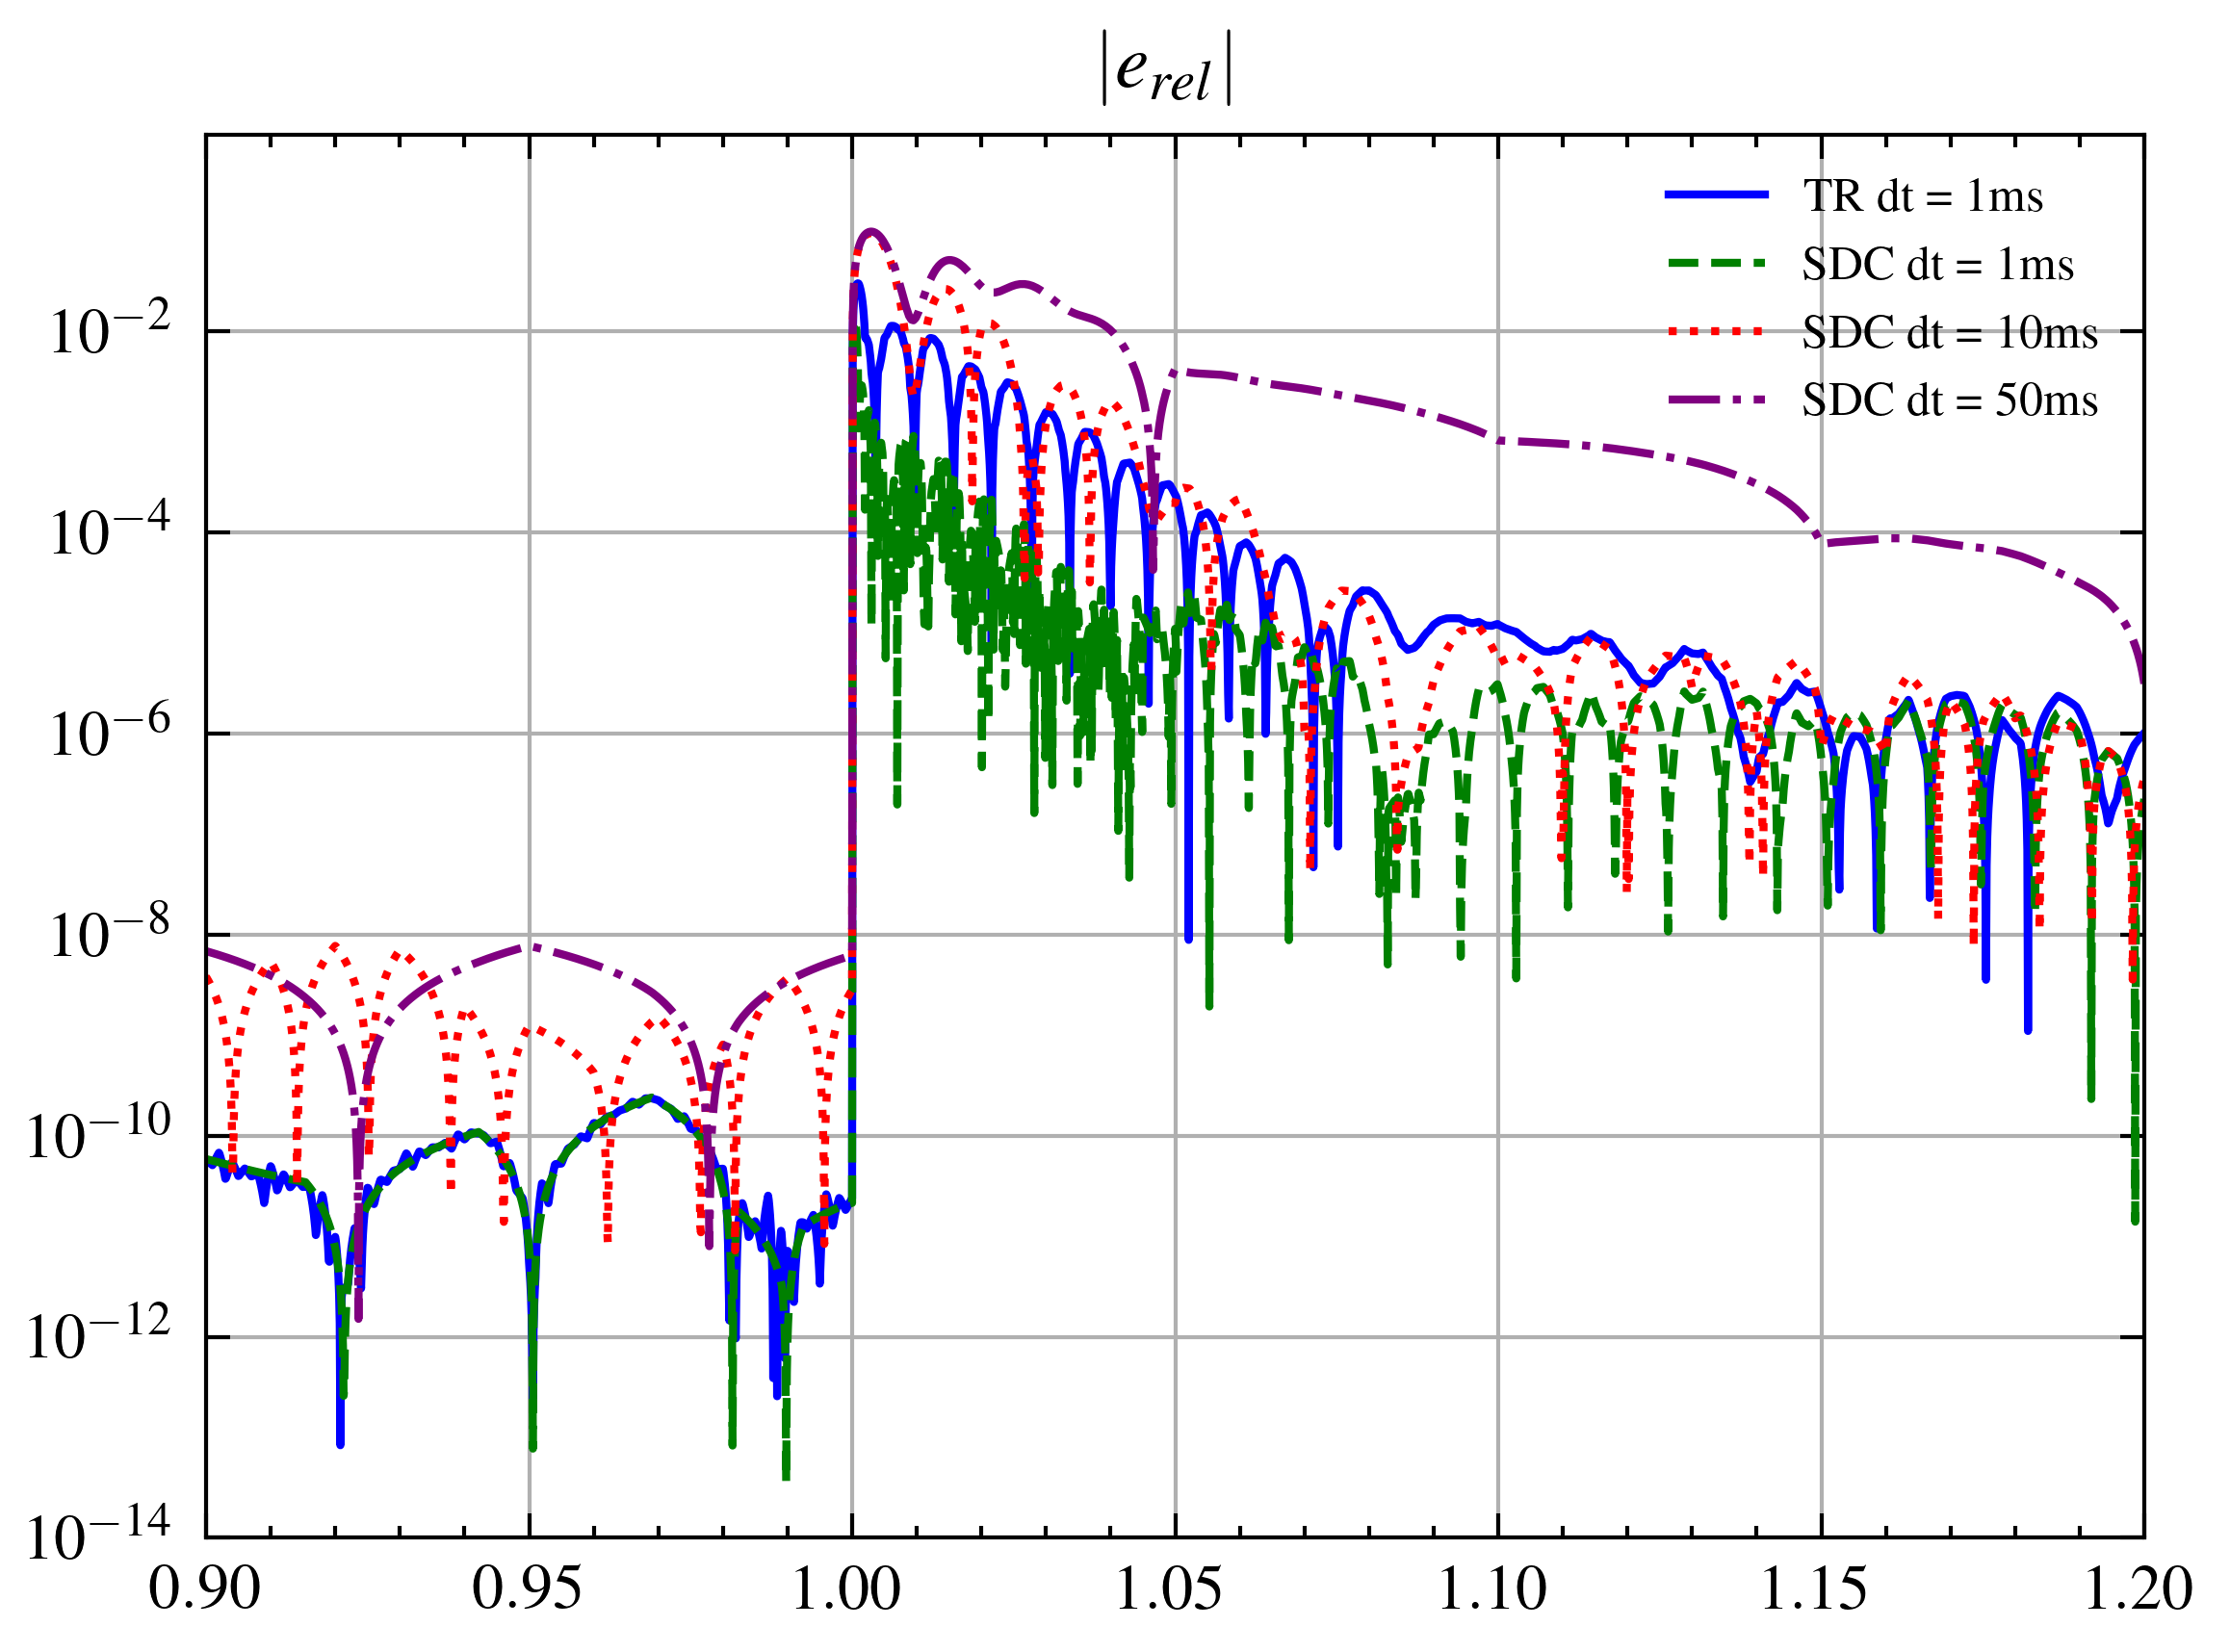

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
# ax.plot(t_ref, rel_error_ode15s, label='ode15s')
ax.plot(t_ref, rel_errors['TR_1ms'], color = 'blue',label='TR dt = 1ms')
ax.plot(t_ref, rel_errors['sdc_1ms_shifted'], color = 'green', label='SDC dt = 1ms')
ax.plot(t_ref, rel_errors['sdc_10ms_shifted'], color = 'red',label='SDC dt = 10ms')
ax.plot(t_ref, rel_errors['sdc_50ms_shifted'], color = 'purple',label='SDC dt = 50ms')
# ax.plot(t_ref, rel_errors['sdc_100ms_shifted'], label='SDC dt = 100ms')
# ax.plot(t_ref, rel_error_sdc_10ms, label='SDC dt = 10ms ')

ax.legend(loc='best', fontsize=6)
ax.set_title('$|e_{rel}|$')
# ax.set_ylim(-1e-3, 0.05)
ax.set_ylim(1e-14, 9e-1)
ax.set_xlim(0.9, 1.2)
ax.set_yscale('log')
ax.grid(True)
plt.tight_layout()
plt.show()
# plt_helper.plt.savefig('fig/error_v_pcc_compare.pdf', dpi=300)



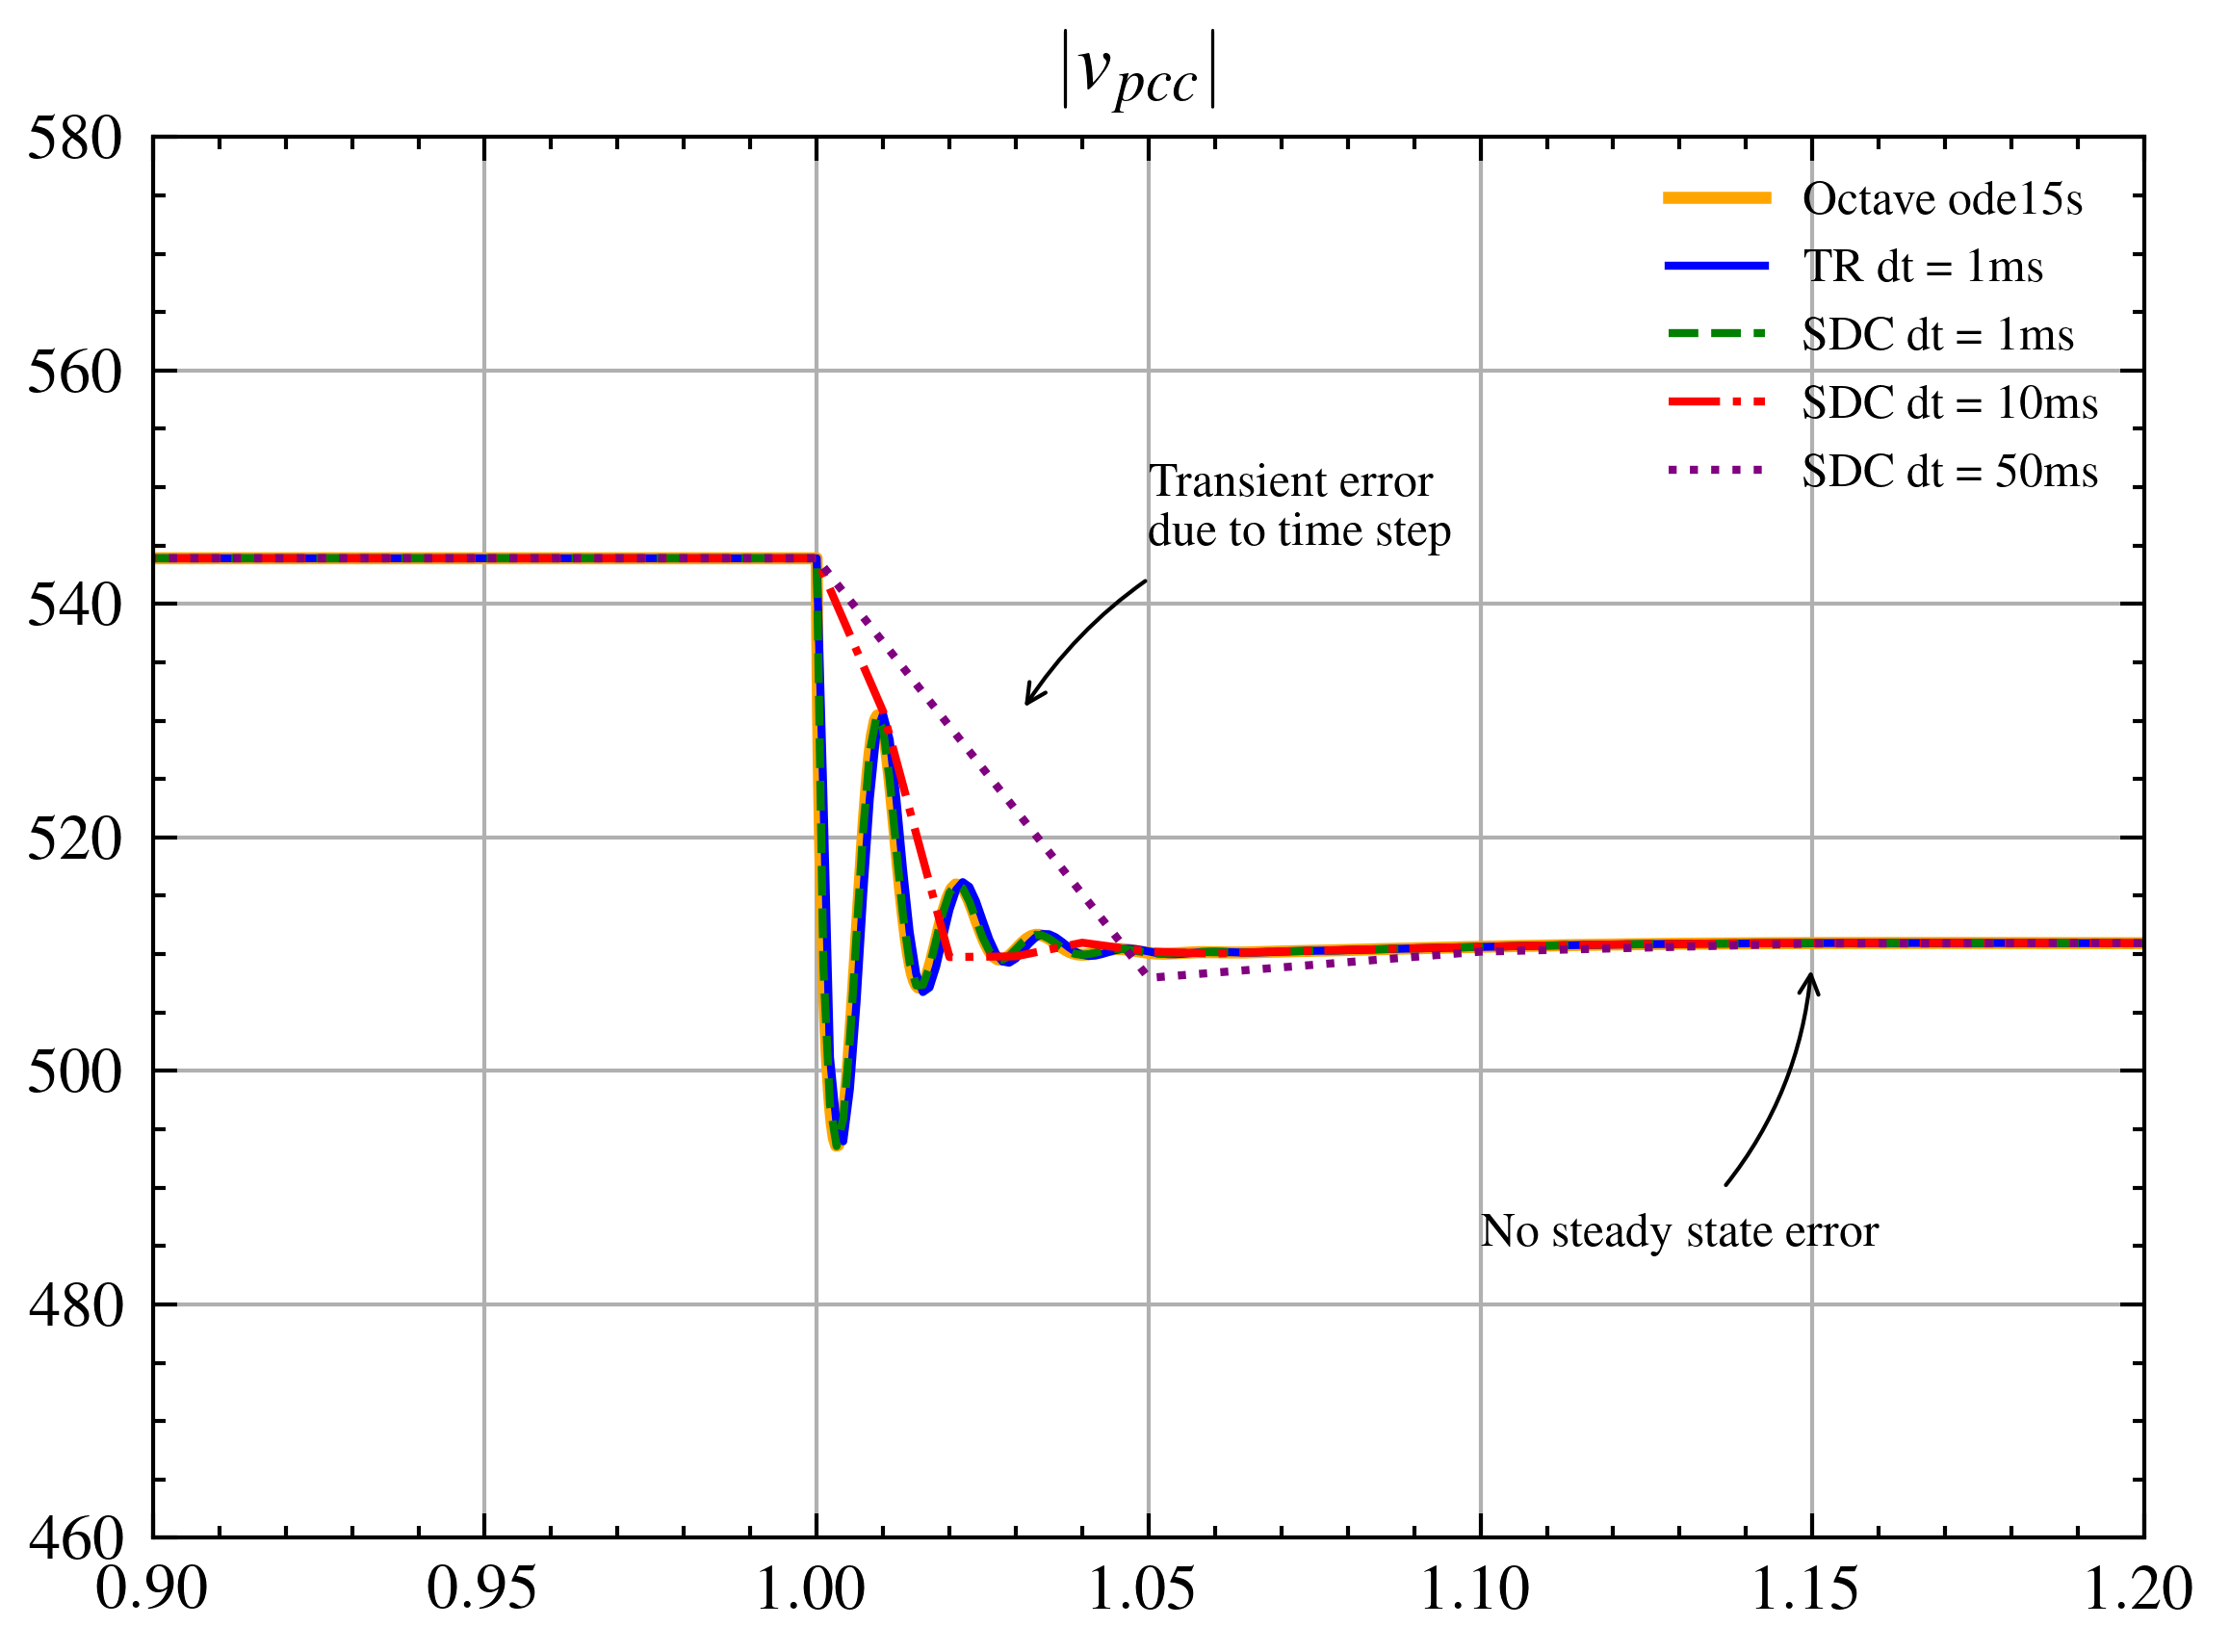

In [7]:
fig, ax = plt_helper.plt.subplots(1, 1, figsize=(4, 3))

# Plot each curve with a distinct color and line style
ax.plot(data['t_ode15s'], magnitudes['v_ode15s'], label='Octave ode15s', 
        color='orange', linestyle='-', linewidth=1.5)
ax.plot(ts_TR, magnitudes['v_TR_1ms'], label='TR dt = 1ms', 
        color='blue', linestyle='-', linewidth=1)
ax.plot(t_sdc_1ms_shifted, magnitudes['v_sdc_1ms'], label='SDC dt = 1ms', 
        color='green', linestyle='--', linewidth=1)
ax.plot(t_sdc_10ms_shifted, magnitudes['v_sdc_10ms'], label='SDC dt = 10ms', 
        color='red', linestyle='-.', linewidth=1)
ax.plot(t_sdc_50ms_shifted, magnitudes['v_sdc_50ms'], label='SDC dt = 50ms', 
        color='purple', linestyle=':', linewidth=1)

# Adjust legend and axis properties
ax.legend(loc='best', fontsize=6)
ax.set_title('$|v_{pcc}|$', fontsize=10)
ax.set_ylim(460, 580)
ax.set_xlim(0.9, 1.2)
ax.grid(True)

ax.annotate('Transient error \n due to time step',
            xy=(1.03, 530),
            xytext=(1.05, 545),
            arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=0.2', linewidth=0.5),
            fontsize=6)

ax.annotate('No steady state error',
            xy=(1.15, 510),
            xytext=(1.10, 485),
            arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=0.2', linewidth=0.5),
            fontsize=6)



plt_helper.plt.tight_layout()
plt_helper.plt.show()
# plt_helper.plt.savefig('fig/v_pcc_compare.pdf', dpi=300)


## computation

In [ ]:
# # Run the single_run function with different restol values
# # restol_values = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]
# newtontol_values = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]
# results_nt = {}
# sdc_time = {}
# restol=1e-2
# for nttol in newtontol_values:
#     start_time = time.time()
#     run_name, ts, res = single_run(f"test_restol_{restol}_nttol_{nttol}", 1e-3, 1.2, FullyImplicitDAE, restol=restol, newtontol=nttol)
#     print(f"{nttol} done")
#     end_time = time.time()
#     sdc_time[nttol] = end_time - start_time
    
#     np.savetxt(f"data/v_pccDQ_sdc_1ms_restol_{restol}_nttol_{nttol}.csv", res["v_g1DQ"], delimiter=",")
#     np.savetxt(f"data/ts_sdc_1ms_restol_{restol}_nttol_{nttol}.csv", ts, delimiter=",")
#     pickle.dump(res, open(f"data/res_sdc_1ms_restol_{restol}_nttol_{nttol}.p", 'wb'))

    
# np.savetxt(f"data/sdc_restol_time_restol_{restol}_nttols.csv", list(sdc_time.items()), delimiter=",", fmt='%s')

0.01 done
0.0001 done
1e-06 done
1e-08 done
1e-10 done


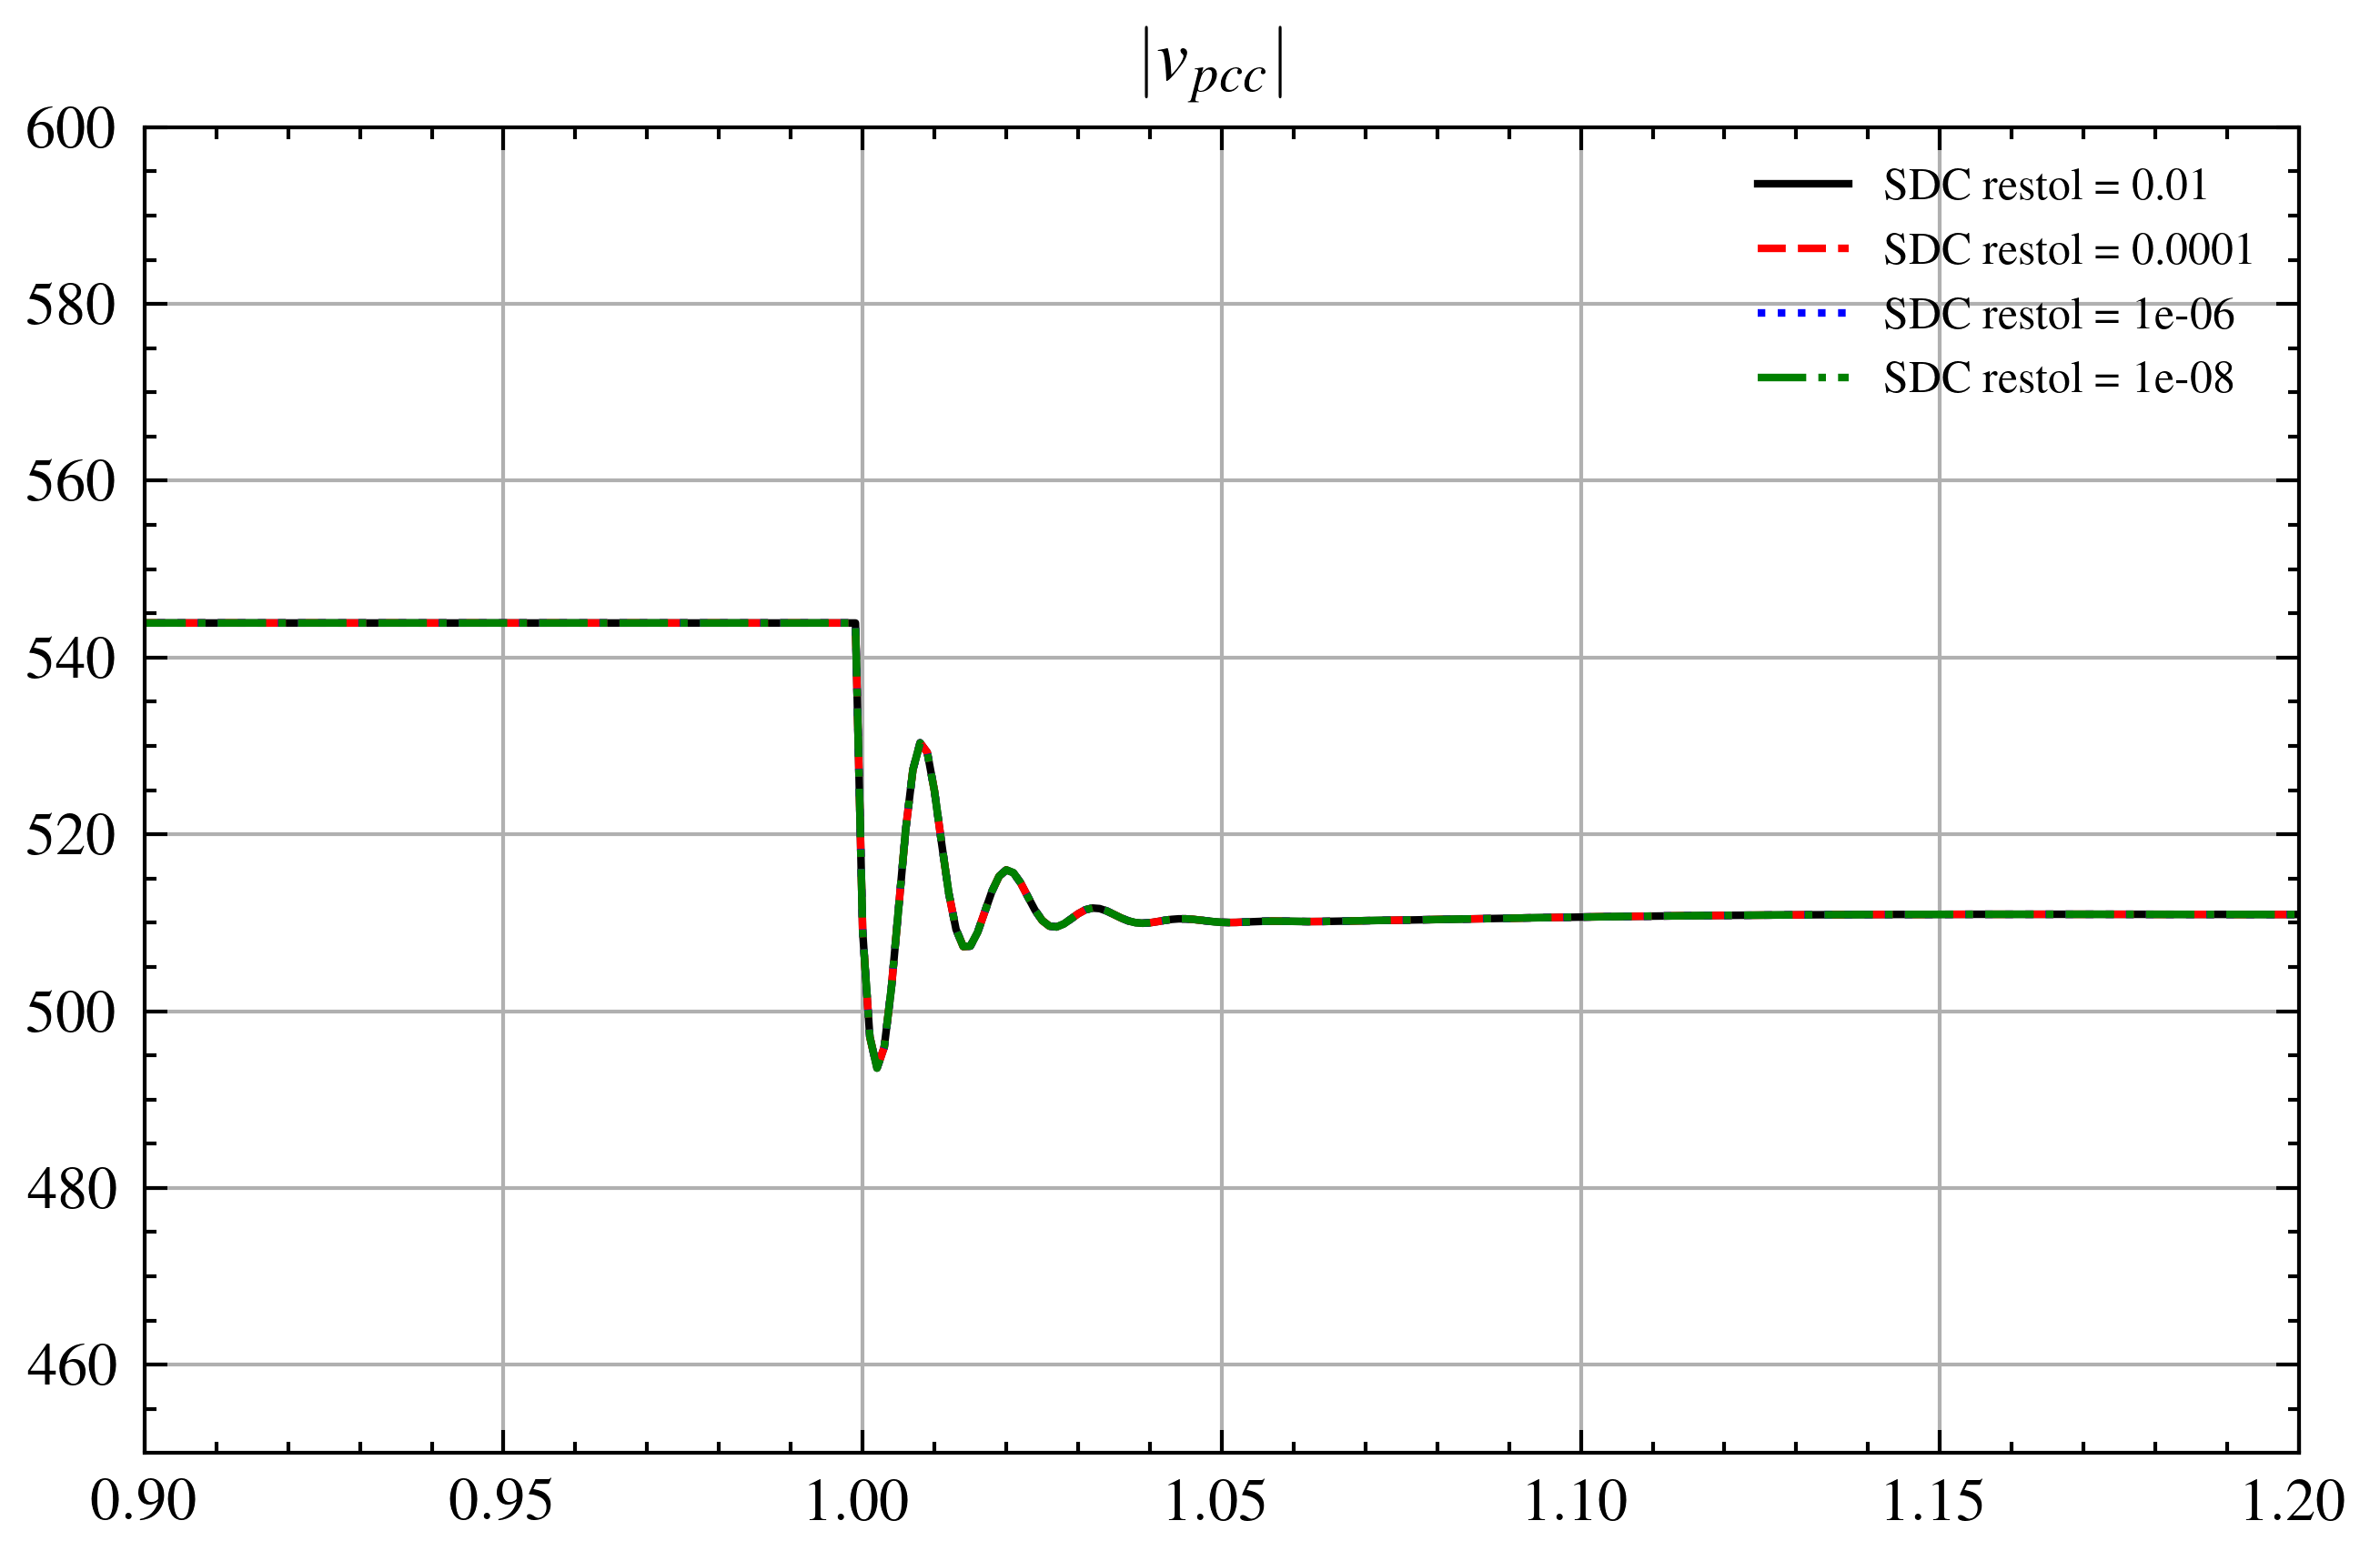

In [8]:
# Load the saved results for each restol value
restol_values = [1e-2, 1e-4, 1e-6, 1e-8]
results = {}

for restol in restol_values:
    ts = np.loadtxt(f"data/ts_sdc_1ms_restol_{restol}.csv", delimiter=',')
    v_pccDQ = np.loadtxt(f"data/v_pccDQ_sdc_1ms_restol_{restol}.csv", delimiter=',')
    results[restol] = (ts, v_pccDQ)

# Plot the results
fig, ax = plt_helper.plt.subplots(1, 1, figsize=(4.5, 3))

for restol, (ts, v_pccDQ) in results.items():
    v_pcc_mag = np.sqrt(v_pccDQ[:, 0]**2 + v_pccDQ[:, 1]**2)
    ax.plot(ts, v_pcc_mag, label=f'SDC restol = {restol}')

ax.legend(loc='best', fontsize=6)
ax.set_title('$|v_{pcc}|$')
ax.set_ylim(450, 600)
ax.set_xlim(0.9, 1.2)
ax.grid(True)

plt_helper.plt.tight_layout()
plt_helper.plt.show()


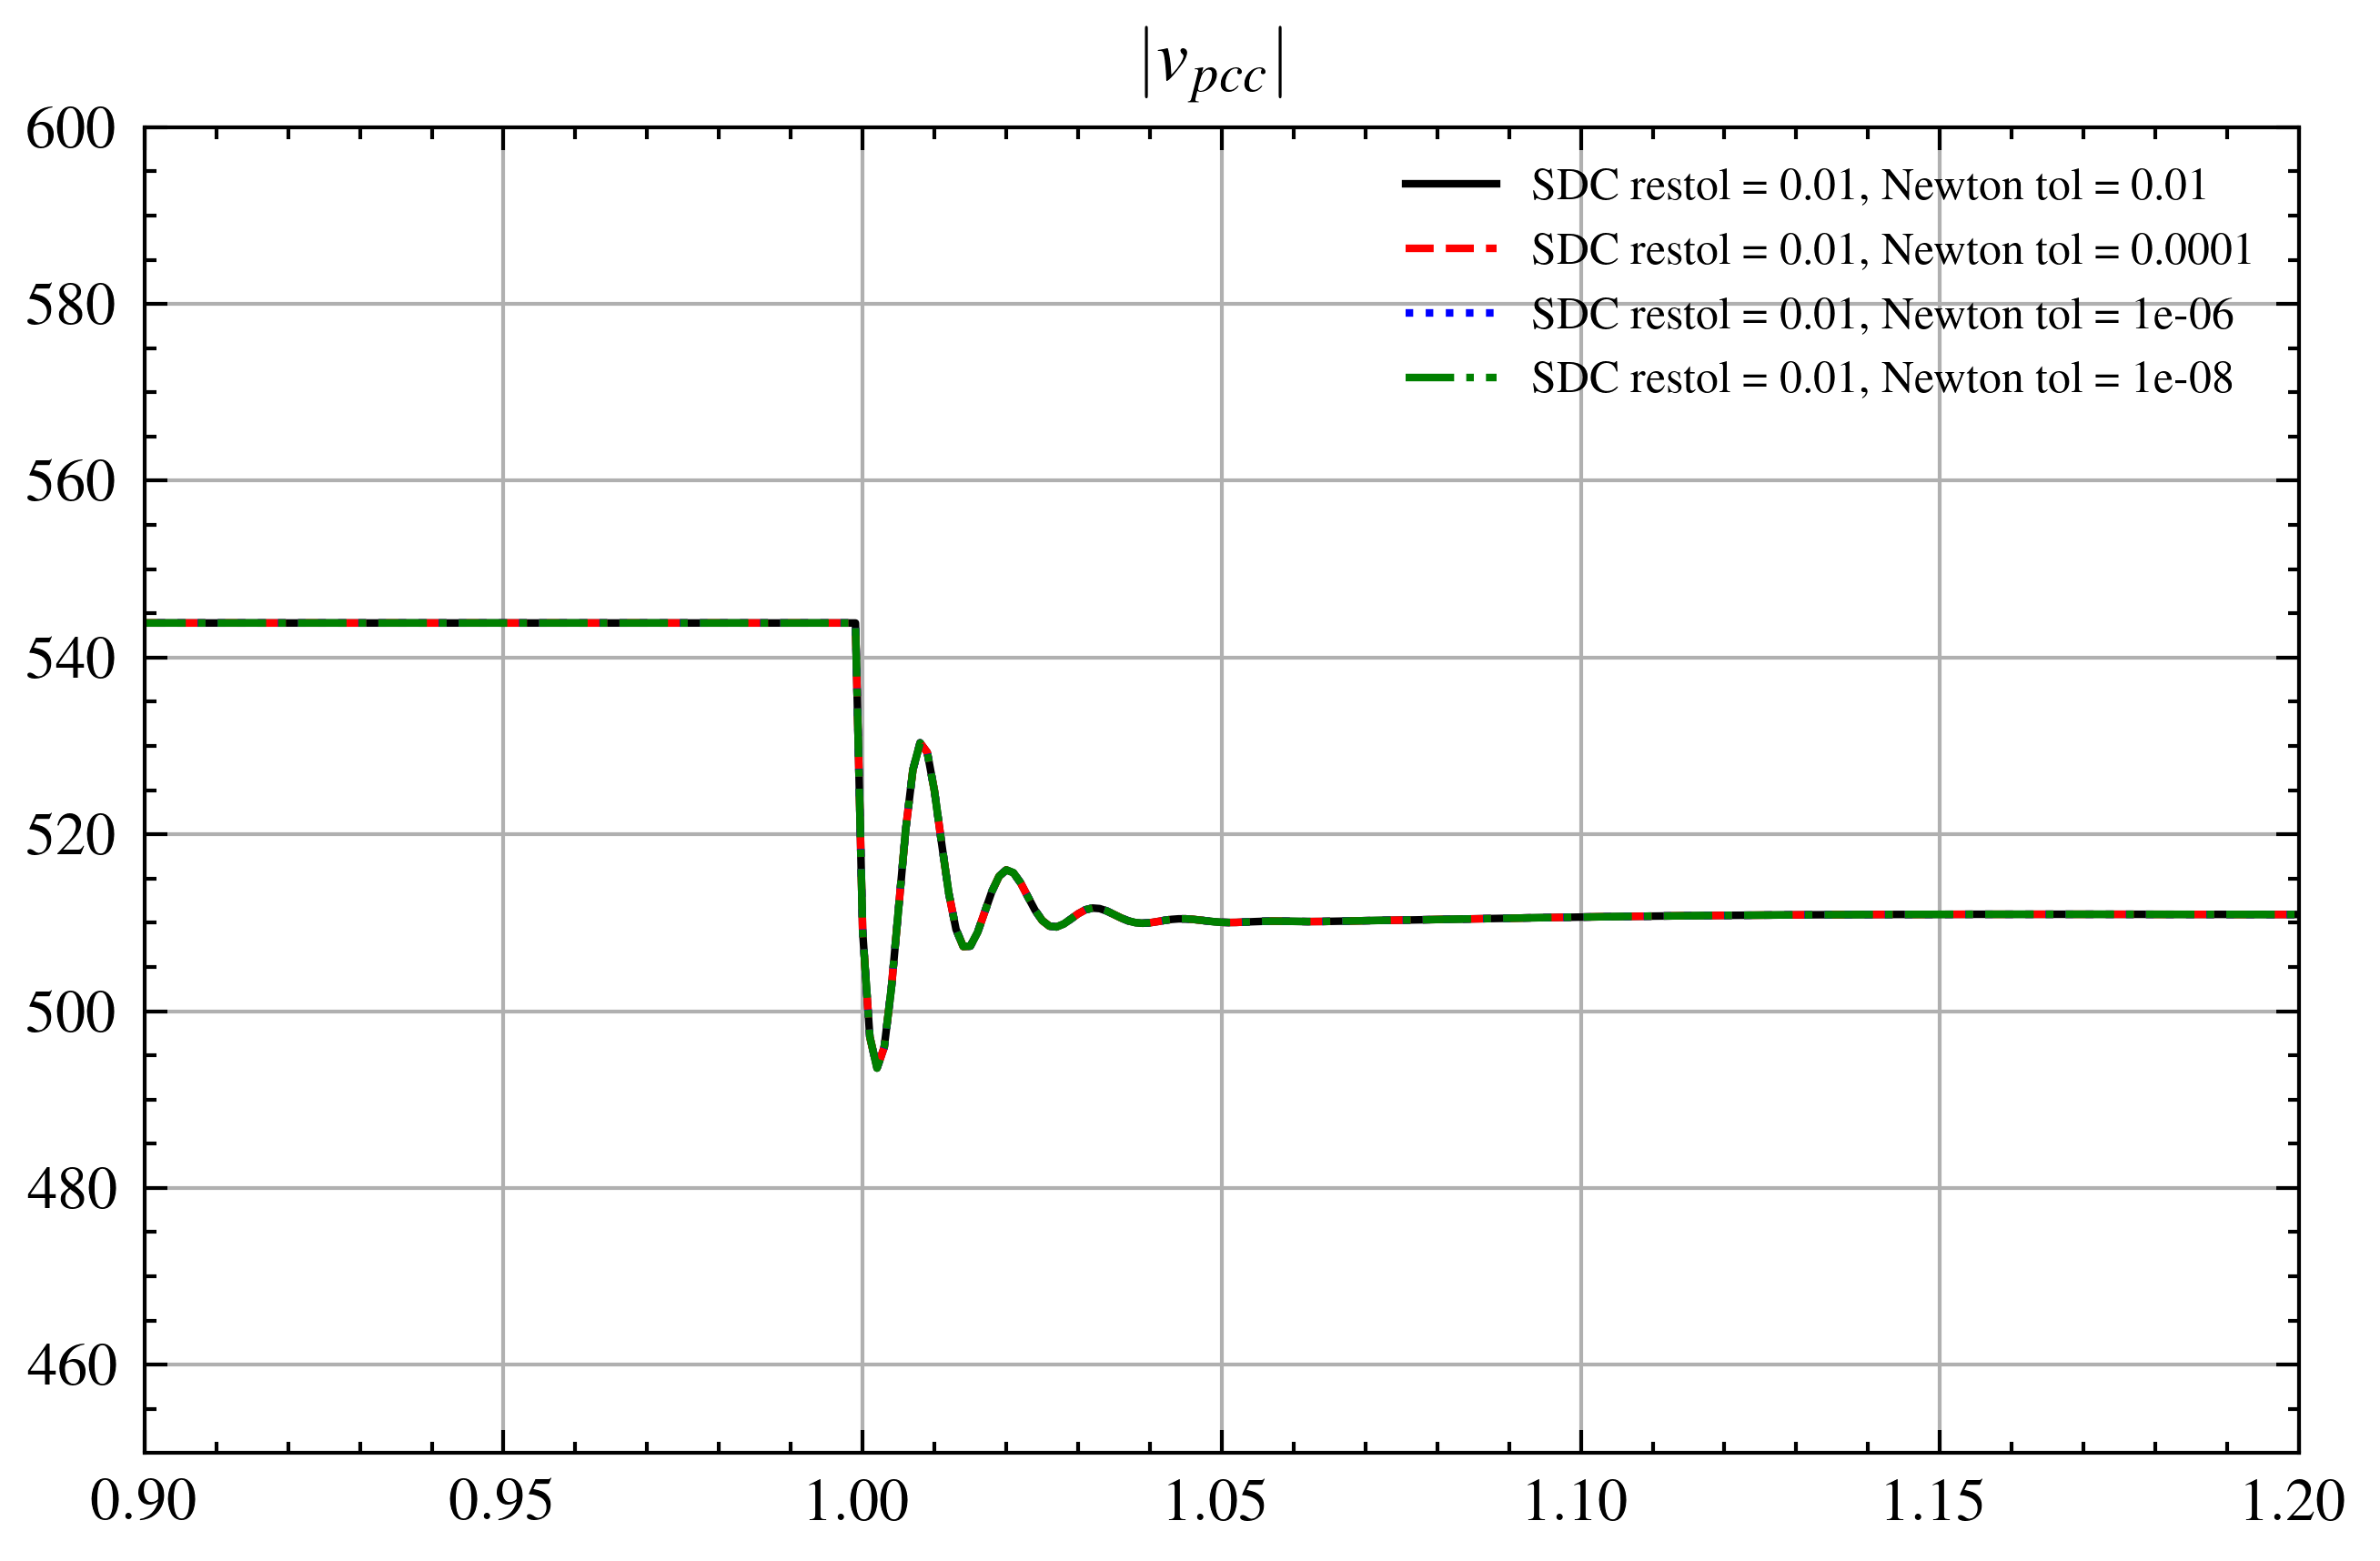

In [9]:
# Load the saved results for each restol value
newtontol_values = [1e-2, 1e-4, 1e-6, 1e-8]
results = {}
restol=1e-2

for nttol in newtontol_values:
    ts = np.loadtxt(f"data/ts_sdc_1ms_restol_{restol}_nttol_{nttol}.csv", delimiter=',')
    v_pccDQ = np.loadtxt(f"data/v_pccDQ_sdc_1ms_restol_{restol}_nttol_{nttol}.csv", delimiter=',')
    results[nttol] = (ts, v_pccDQ)

# Plot the results
fig, ax = plt_helper.plt.subplots(1, 1, figsize=(4.5, 3))

for nttol, (ts, v_pccDQ) in results.items():
    v_pcc_mag = np.sqrt(v_pccDQ[:, 0]**2 + v_pccDQ[:, 1]**2)
    ax.plot(ts, v_pcc_mag, label=f'SDC restol = {restol}, Newton tol = {nttol}')

ax.legend(loc='best', fontsize=6)
ax.set_title('$|v_{pcc}|$')
ax.set_ylim(450, 600)
ax.set_xlim(0.9, 1.2)
ax.grid(True)

plt_helper.plt.tight_layout()
plt_helper.plt.show()


In [13]:
import pandas as pd

# ---------------------------
# 1. Load timing data (from data/ folder)
# ---------------------------
df_restol = pd.read_csv('data/sdc_restol_time.csv', header=None, names=['restol', 'time'])
df_nttol = pd.read_csv('data/sdc_restol_time_restol_0.01_nttols.csv', header=None, names=['nttol', 'time'])

# Compute speedup factors (speedup = time(lowest tolerance) / time(current))
# For restol study, the lowest tolerance is the smallest restol (assumed 1e-10)
ref_restol_value = df_restol['restol'].min()
ref_restol_time = df_restol.loc[df_restol['restol'] == ref_restol_value, 'time'].iloc[0]
df_restol['speedup'] = ref_restol_time / df_restol['time']

# For nttol study (restol fixed at 0.01), the lowest tolerance is the smallest nttol (assumed 1e-10)
ref_nttol_value = df_nttol['nttol'].min()
ref_nttol_time = df_nttol.loc[df_nttol['nttol'] == ref_nttol_value, 'time'].iloc[0]
df_nttol['speedup'] = ref_nttol_time / df_nttol['time']

# ---------------------------
# 2. Compute accuracy errors for simulation results
# ---------------------------
# Study 1: Fixed restol=0.01, varying nttol
nttol_values = [0.01, 0.0001, 1e-6, 1e-8, 1e-10]
# Use the most stringent nttol (lowest) as the reference.
ref_nttol = 1e-10  
# ref_file = f"data/v_pccDQ_sdc_1ms_restol_0.01_nttol_{ref_nttol}.csv"
ref_file = f"data/v_pccDQ_sdc_1ms_restol_1e-12.csv"
ref_data = pd.read_csv(ref_file, header=None)


errors_nttol = {}
for tol in nttol_values:
    file = f"data/v_pccDQ_sdc_1ms_restol_0.01_nttol_{tol}.csv"
    data = pd.read_csv(file, header=None)
    # Compute RMSE error over all elements
    error = np.sqrt(((data - ref_data) ** 2).mean().mean())
    errors_nttol[tol] = error

# Study 2: Fixed nttol=1e-10, varying restol
restol_values = [0.01, 0.0001, 1e-6, 1e-8, 1e-10]
# Use the smallest restol as the reference.
ref_restol = 1e-10  
ref_file_restol = f"data/v_pccDQ_sdc_1ms_restol_{ref_restol}.csv"
ref_data_restol = pd.read_csv(ref_file_restol, header=None)

errors_restol = {}
for tol in restol_values:
    file = f"data/v_pccDQ_sdc_1ms_restol_{tol}.csv"
    data = pd.read_csv(file, header=None)
    error = np.sqrt(((data - ref_data_restol) ** 2).mean().mean())
    errors_restol[tol] = error

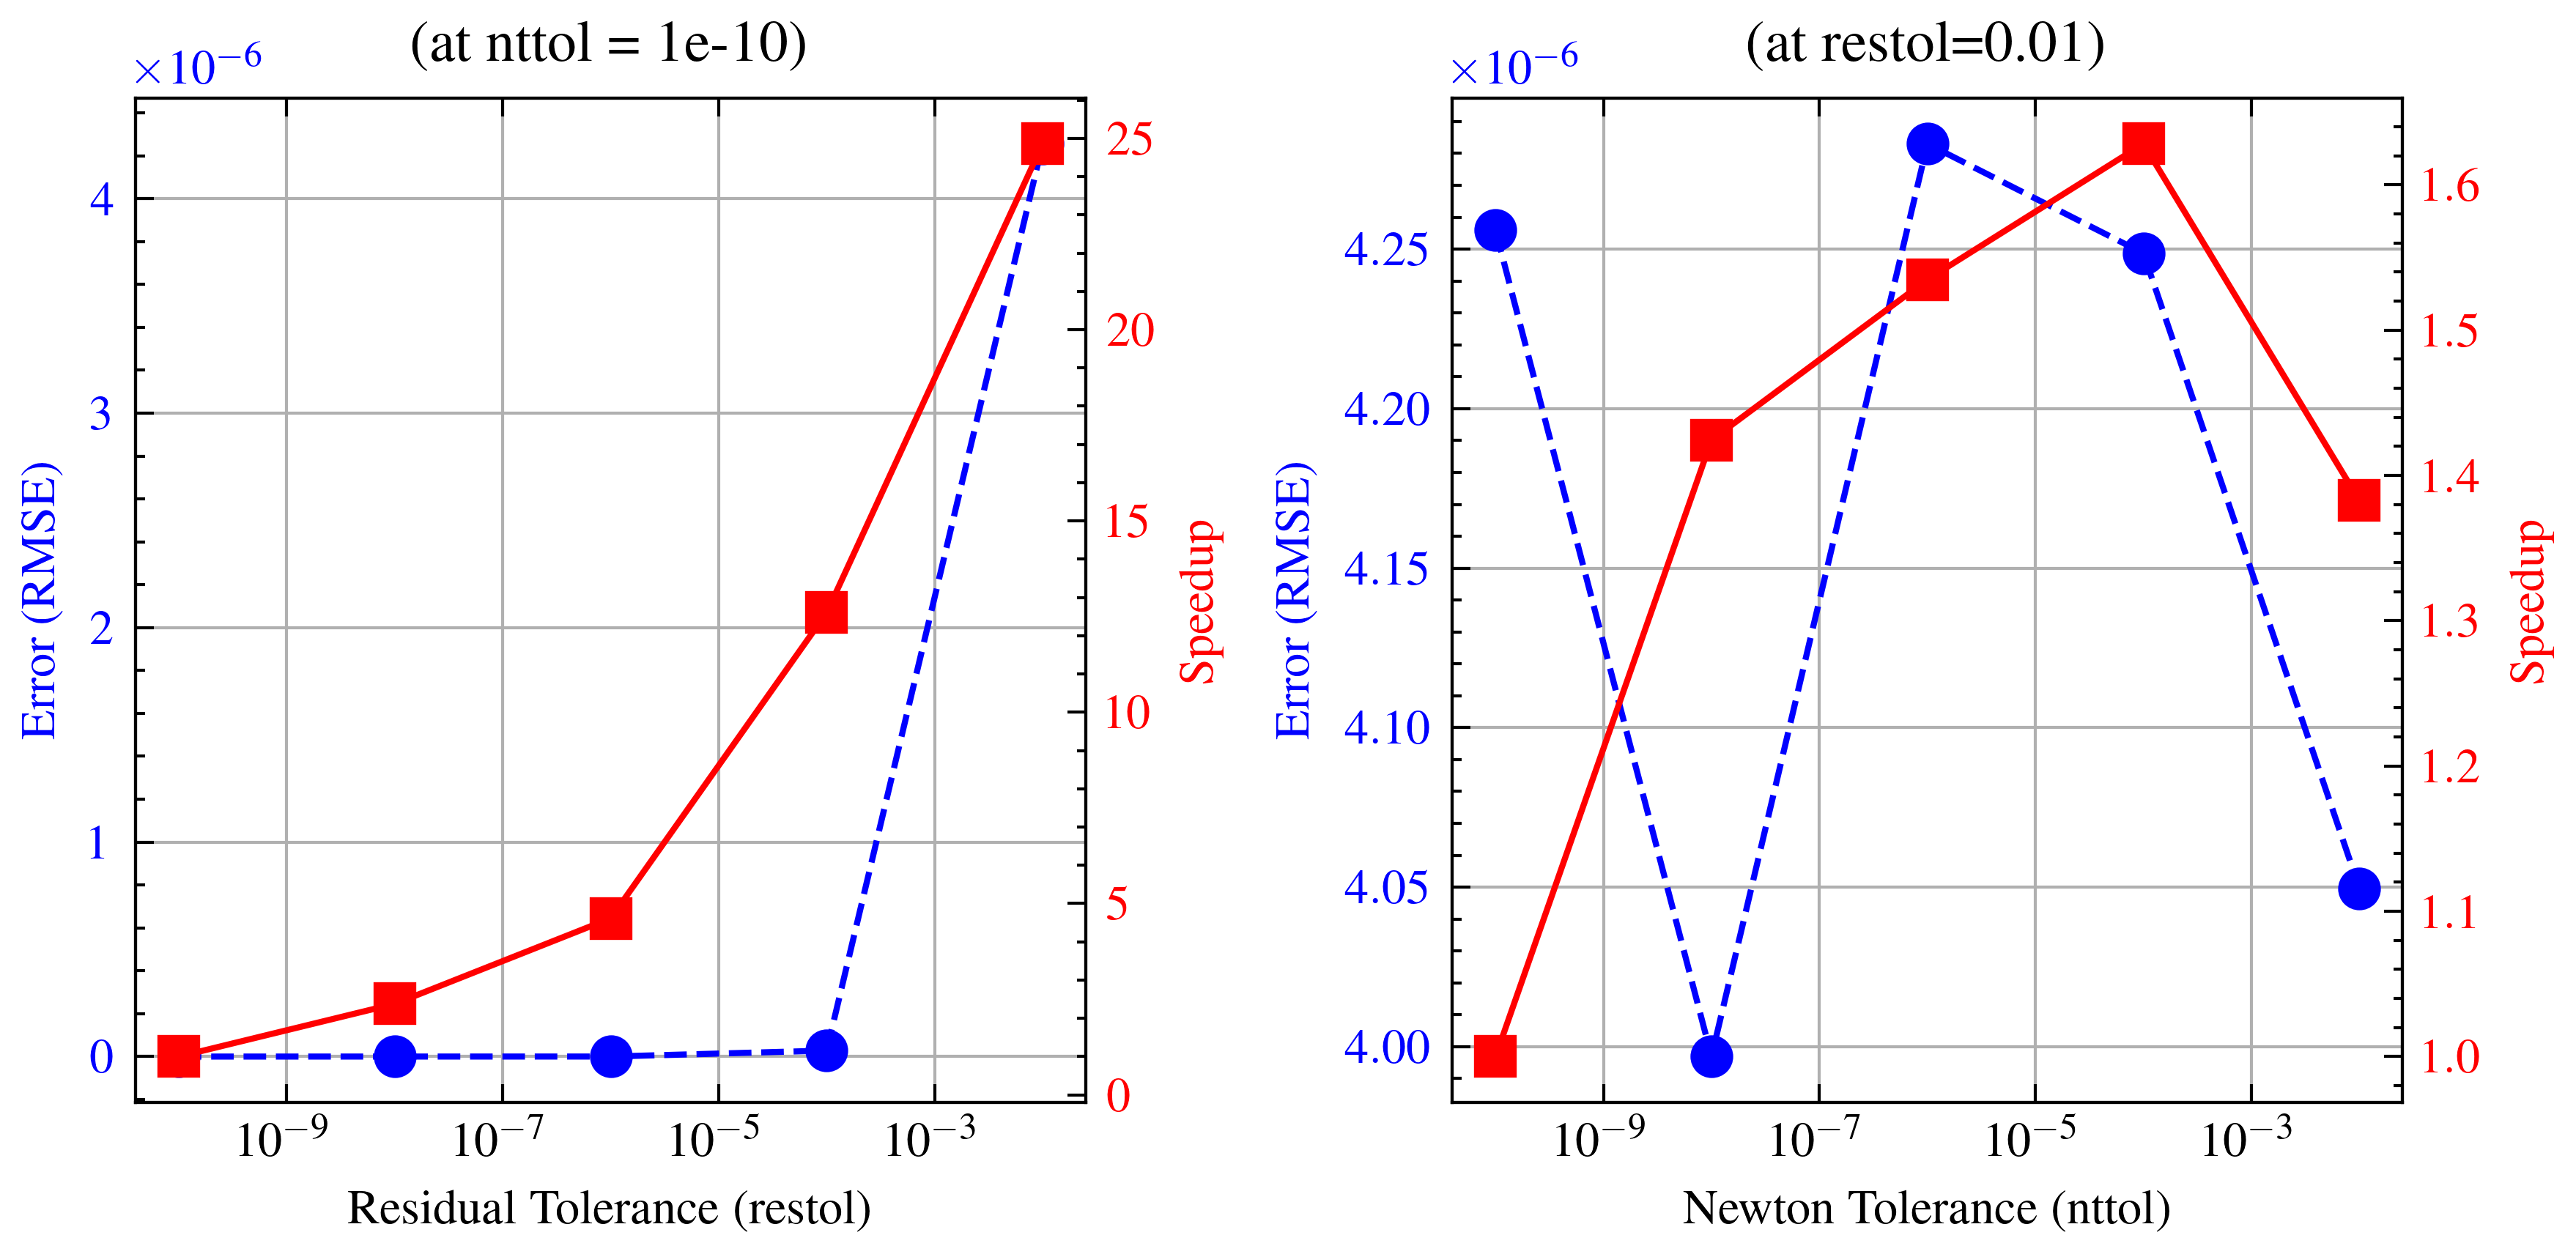

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

ax1 = axs[0]
restol_keys = sorted(errors_restol.keys())
error_vals_restol = [errors_restol[k] for k in restol_keys]
ax1.plot(restol_keys, error_vals_restol, marker='o', color='blue', linestyle='--', label='Error (RMSE)')
ax1.set_xscale('log')
ax1.set_xlabel('Residual Tolerance (restol)')
ax1.set_ylabel('Error (RMSE)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
# ax1.set_title('Speedup and Error with \n residual tolerance \n (at nttol = 1e-10)')
ax1.set_title('(at nttol = 1e-10)')
ax1.grid(True)
# Twin axis for speedup data using restol timing data
restol_speedup = [df_restol.loc[df_restol['restol'] == tol, 'speedup'].iloc[0] for tol in restol_keys]
ax1b = ax1.twinx()
ax1b.plot(restol_keys, restol_speedup, marker='s', color='red', label='Speedup')
ax1b.set_ylabel('Speedup', color='red')
ax1b.tick_params(axis='y', labelcolor='red')


# Subplot 2: Accuracy (RMSE error) and speedup vs restol (nttol fixed at 1e-10)
ax2 = axs[1]

nttol_keys = sorted(errors_nttol.keys())
error_vals = [errors_nttol[k] for k in nttol_keys]
ax2.plot(nttol_keys, error_vals, marker='o', color='blue', linestyle='--', label='Error (RMSE)')
ax2.set_xscale('log')
ax2.set_xlabel('Newton Tolerance (nttol)')
ax2.set_ylabel('Error (RMSE)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
# ax2.set_title('Speedup and Error with \n Newton tolerance \n  (at restol=0.01)')
ax2.set_title('(at restol=0.01)')
ax2.grid(True)

# Twin axis for speedup data
ax2b = ax2.twinx()
# Make sure nttol keys in df_nttol are sorted similarly
nttol_speedup = [df_nttol.loc[df_nttol['nttol'] == tol, 'speedup'].iloc[0] for tol in nttol_keys]
ax2b.plot(nttol_keys, nttol_speedup, marker='s', color='red', label='Speedup')
ax2b.set_ylabel('Speedup', color='red')
ax2b.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()
# plt_helper.plt.savefig('fig/speedup_error_restol_nttol.pdf', dpi=300)



## archiv


In [ ]:
# v_pcc_sdc_10ms = np.loadtxt('data/v_pccDQ_sdc_10ms.csv', delimiter=',')
# t_sdc_10ms = np.loadtxt('data/ts_sdc_10ms.csv', delimiter=',')

# v_pcc_sdc_50ms = np.loadtxt('data/v_pccDQ_sdc_50ms.csv', delimiter=',')
# t_sdc_50ms = np.loadtxt('data/ts_sdc_50ms.csv', delimiter=',')

# v_pcc_sdc_100ms = np.loadtxt('data/v_pccDQ_sdc_100ms.csv', delimiter=',')
# t_sdc_100ms = np.loadtxt('data/ts_sdc_100ms.csv', delimiter=',')

# v_pcc_sdc_500ms = np.loadtxt('data/v_pccDQ_sdc_500ms.csv', delimiter=',')
# t_sdc_500ms = np.loadtxt('data/ts_sdc_500ms.csv', delimiter=',')


# v_pcc_sdc_1ms = np.loadtxt('data/v_pccDQ_sdc_1ms.csv', delimiter=',')
# t_sdc_1ms = np.loadtxt('data/ts_sdc_1ms.csv', delimiter=',')

# v_pcc_be_1ms = np.loadtxt('data/threeVSC_octave_res/v_pcc_be_1ms.csv', delimiter=',')
# v_pcc_TR_1ms = np.loadtxt('data/threeVSC_octave_res/v_pcc_TR_1ms.csv', delimiter=',')
# v_pcc_rk4_100us = np.loadtxt('data/threeVSC_octave_res/v_pcc_rk4_100us.csv', delimiter=',')
# t_ode15s = np.loadtxt('data/threeVSC_octave_res/t_ode15s.csv', delimiter=',')
# v_pcc_ode15s = np.loadtxt('data/threeVSC_octave_res/v_pcc_ode15s.csv', delimiter=',')
# # Determine the number of rows in the CSV file.
# num_rows = v_pcc_be_1ms.shape[0]
# num_rows2 = v_pcc_rk4_100us.shape[0]
# num_rows_TR = v_pcc_TR_1ms.shape[0]

# # Generate time stamps evenly spaced over a total duration of 1.2 seconds.
# ts_ = np.linspace(0, 1.2, num=num_rows+1)
# ts_2 = np.linspace(0, 1.2, num=num_rows2+1)
# ts_TR = np.linspace(0, 1.5, num=num_rows_TR+1)
# ts_be_1ms = ts_[1:]
# ts_rk4_100us = ts_2[1:]
# ts_TR_1ms = ts_TR[1:]

In [ ]:
# v_pcc_sdc_500ms_mag = np.sqrt(v_pcc_sdc_500ms[:, 0]**2 + v_pcc_sdc_500ms[:, 1]**2)

# v_pcc_sdc_100ms_mag = np.sqrt(v_pcc_sdc_100ms[:, 0]**2 + v_pcc_sdc_100ms[:, 1]**2)
# v_pcc_sdc_10ms_mag = np.sqrt(v_pcc_sdc_10ms[:, 0]**2 + v_pcc_sdc_10ms[:, 1]**2)
# v_pcc_sdc_50ms_mag = np.sqrt(v_pcc_sdc_50ms[:, 0]**2 + v_pcc_sdc_50ms[:, 1]**2)
# v_pcc_sdc_1ms_mag = np.sqrt(v_pcc_sdc_1ms[:, 0]**2 + v_pcc_sdc_1ms[:, 1]**2)

# v_pcc_rk4_100us_mag = np.sqrt(v_pcc_rk4_100us[:, 0]**2 + v_pcc_rk4_100us[:, 1]**2)
# v_pcc_be_1ms_mag = np.sqrt(v_pcc_be_1ms[:, 0]**2 + v_pcc_be_1ms[:, 1]**2)
# v_pcc_TR_1ms_mag = np.sqrt(v_pcc_TR_1ms[:, 0]**2 + v_pcc_TR_1ms[:, 1]**2)
# v_pcc_ode15s_mag = np.sqrt(v_pcc_ode15s[:, 0]**2 + v_pcc_ode15s[:, 1]**2)

In [ ]:
# # Shift the time array by 1ms
# shift_1ms = 1e-3  # 1ms in seconds
# t_sdc_1ms_shifted = t_sdc_1ms + shift_1ms

# t_sdc_10ms_shifted = t_sdc_10ms + 10e-3


In [ ]:
# fig, ax = plt_helper.plt.subplots(1, 1, figsize=(4.5, 3))
# # ax.plot(t_100, v_pcc_tr_dt100[:, 0], label='TR dt = 0.1ms')
# # ax.plot(ts_rk4_100us, v_pcc_rk4_100us_mag, label='Rk4 dt = 100us')
# # ax.plot(ts_be_1ms, v_pcc_be_1ms_mag,  label='BE dt = 1ms')
# ax.plot(t_ode15s, v_pcc_ode15s_mag,  label='Octave ode15s')
# ax.plot(ts_TR_1ms, v_pcc_TR_1ms_mag,  label='TR dt = 1ms')
# # ax.plot(t_2, v_pcc_tr[:, 0], label='TR dt = 10ms')
# # ax.plot(t_sdc_1ms, v_pcc_sdc_1ms_mag, label='SDC dt = 1ms')
# ax.plot(t_sdc_1ms_shifted, v_pcc_sdc_1ms_mag, label='SDC dt = 1ms')
# # ax.plot(t_sdc_500ms, v_pcc_sdc_500ms_mag, label='SDC dt = 500ms')
# # ax.plot(t_sdc_100ms, v_pcc_sdc_100ms_mag, label='SDC dt = 100ms')
# # ax.plot(t_sdc_50ms, v_pcc_sdc_50ms_mag, label='SDC dt = 50ms')
# # ax.plot(t_sdc_10ms, v_pcc_sdc_10ms_mag, label='SDC dt = 10ms')
# ax.plot(t_sdc_10ms_shifted, v_pcc_sdc_10ms_mag, label='SDC dt = 10ms')
# # ax.plot(t_1ms, v_pcc_sdc_1ms[:, 0], label='SDC dt = 1ms')
# # ax.plot(t, v_pcc[:, 1], label='v_pcc_q')
# ax.legend(loc='best', fontsize=6)
# ax.set_title('$|v_{pcc}|$')
# ax.set_ylim(450,600)
# ax.set_xlim(0.9,1.2)
# ax.grid(True)


# ax.annotate('Transient error \n due to time step',
#             xy=(1.03, 530),
#             xytext=(1.05, 545),
#             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=0.2', linewidth=0.5),
#             fontsize=6)

# ax.annotate('No steady state error',
#             xy=(1.15, 510),
#             xytext=(1.10, 485),
#             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=0.2', linewidth=0.5),
#             fontsize=6)



# plt_helper.plt.tight_layout()
# plt_helper.plt.show()
# # plt_helper.plt.savefig('fig/v_pcc_compare.pdf', dpi=300)


In [ ]:
# Reference time array
t_ref = ts_rk4_100us
v_pcc_ref = np.interp(t_ref, t_ode15s, v_pcc_ode15s_mag)

# Shift the time array by 1ms
v_pcc_sdc_1ms_mag_shifted_interp = np.interp(t_ref, t_sdc_1ms_shifted, v_pcc_sdc_1ms_mag)
v_pcc_sdc_10ms_mag_shifted_interp = np.interp(t_ref, t_sdc_10ms_shifted, v_pcc_sdc_10ms_mag)



# Interpolate other arrays to match the reference time array
v_pcc_TR_1ms_mag_interp = np.interp(t_ref, ts_TR_1ms, v_pcc_TR_1ms_mag)
# v_pcc_ode15s_mag_interp = np.interp(t_ref, t_ode15s, v_pcc_ode15s_mag)
v_pcc_sdc_1ms_mag_interp = np.interp(t_ref, t_sdc_1ms, v_pcc_sdc_1ms_mag)
v_pcc_sdc_10ms_mag_interp = np.interp(t_ref, t_sdc_10ms, v_pcc_sdc_10ms_mag)

rel_error_sdc_1ms_shifted = np.abs((v_pcc_sdc_1ms_mag_shifted_interp - v_pcc_ref)/v_pcc_ref)
rel_error_sdc_10ms_shifted = np.abs((v_pcc_sdc_10ms_mag_shifted_interp - v_pcc_ref)/v_pcc_ref)


rel_error_TR_1ms = np.abs((v_pcc_TR_1ms_mag_interp - v_pcc_ref)/v_pcc_ref)
# rel_error_ode15s = np.abs((v_pcc_ode15s_mag_interp - v_pcc_ref)/v_pcc_ref)
rel_error_sdc_1ms = np.abs((v_pcc_sdc_1ms_mag_interp - v_pcc_ref)/v_pcc_ref)
rel_error_sdc_10ms = np.abs((v_pcc_sdc_10ms_mag_interp - v_pcc_ref)/v_pcc_ref)


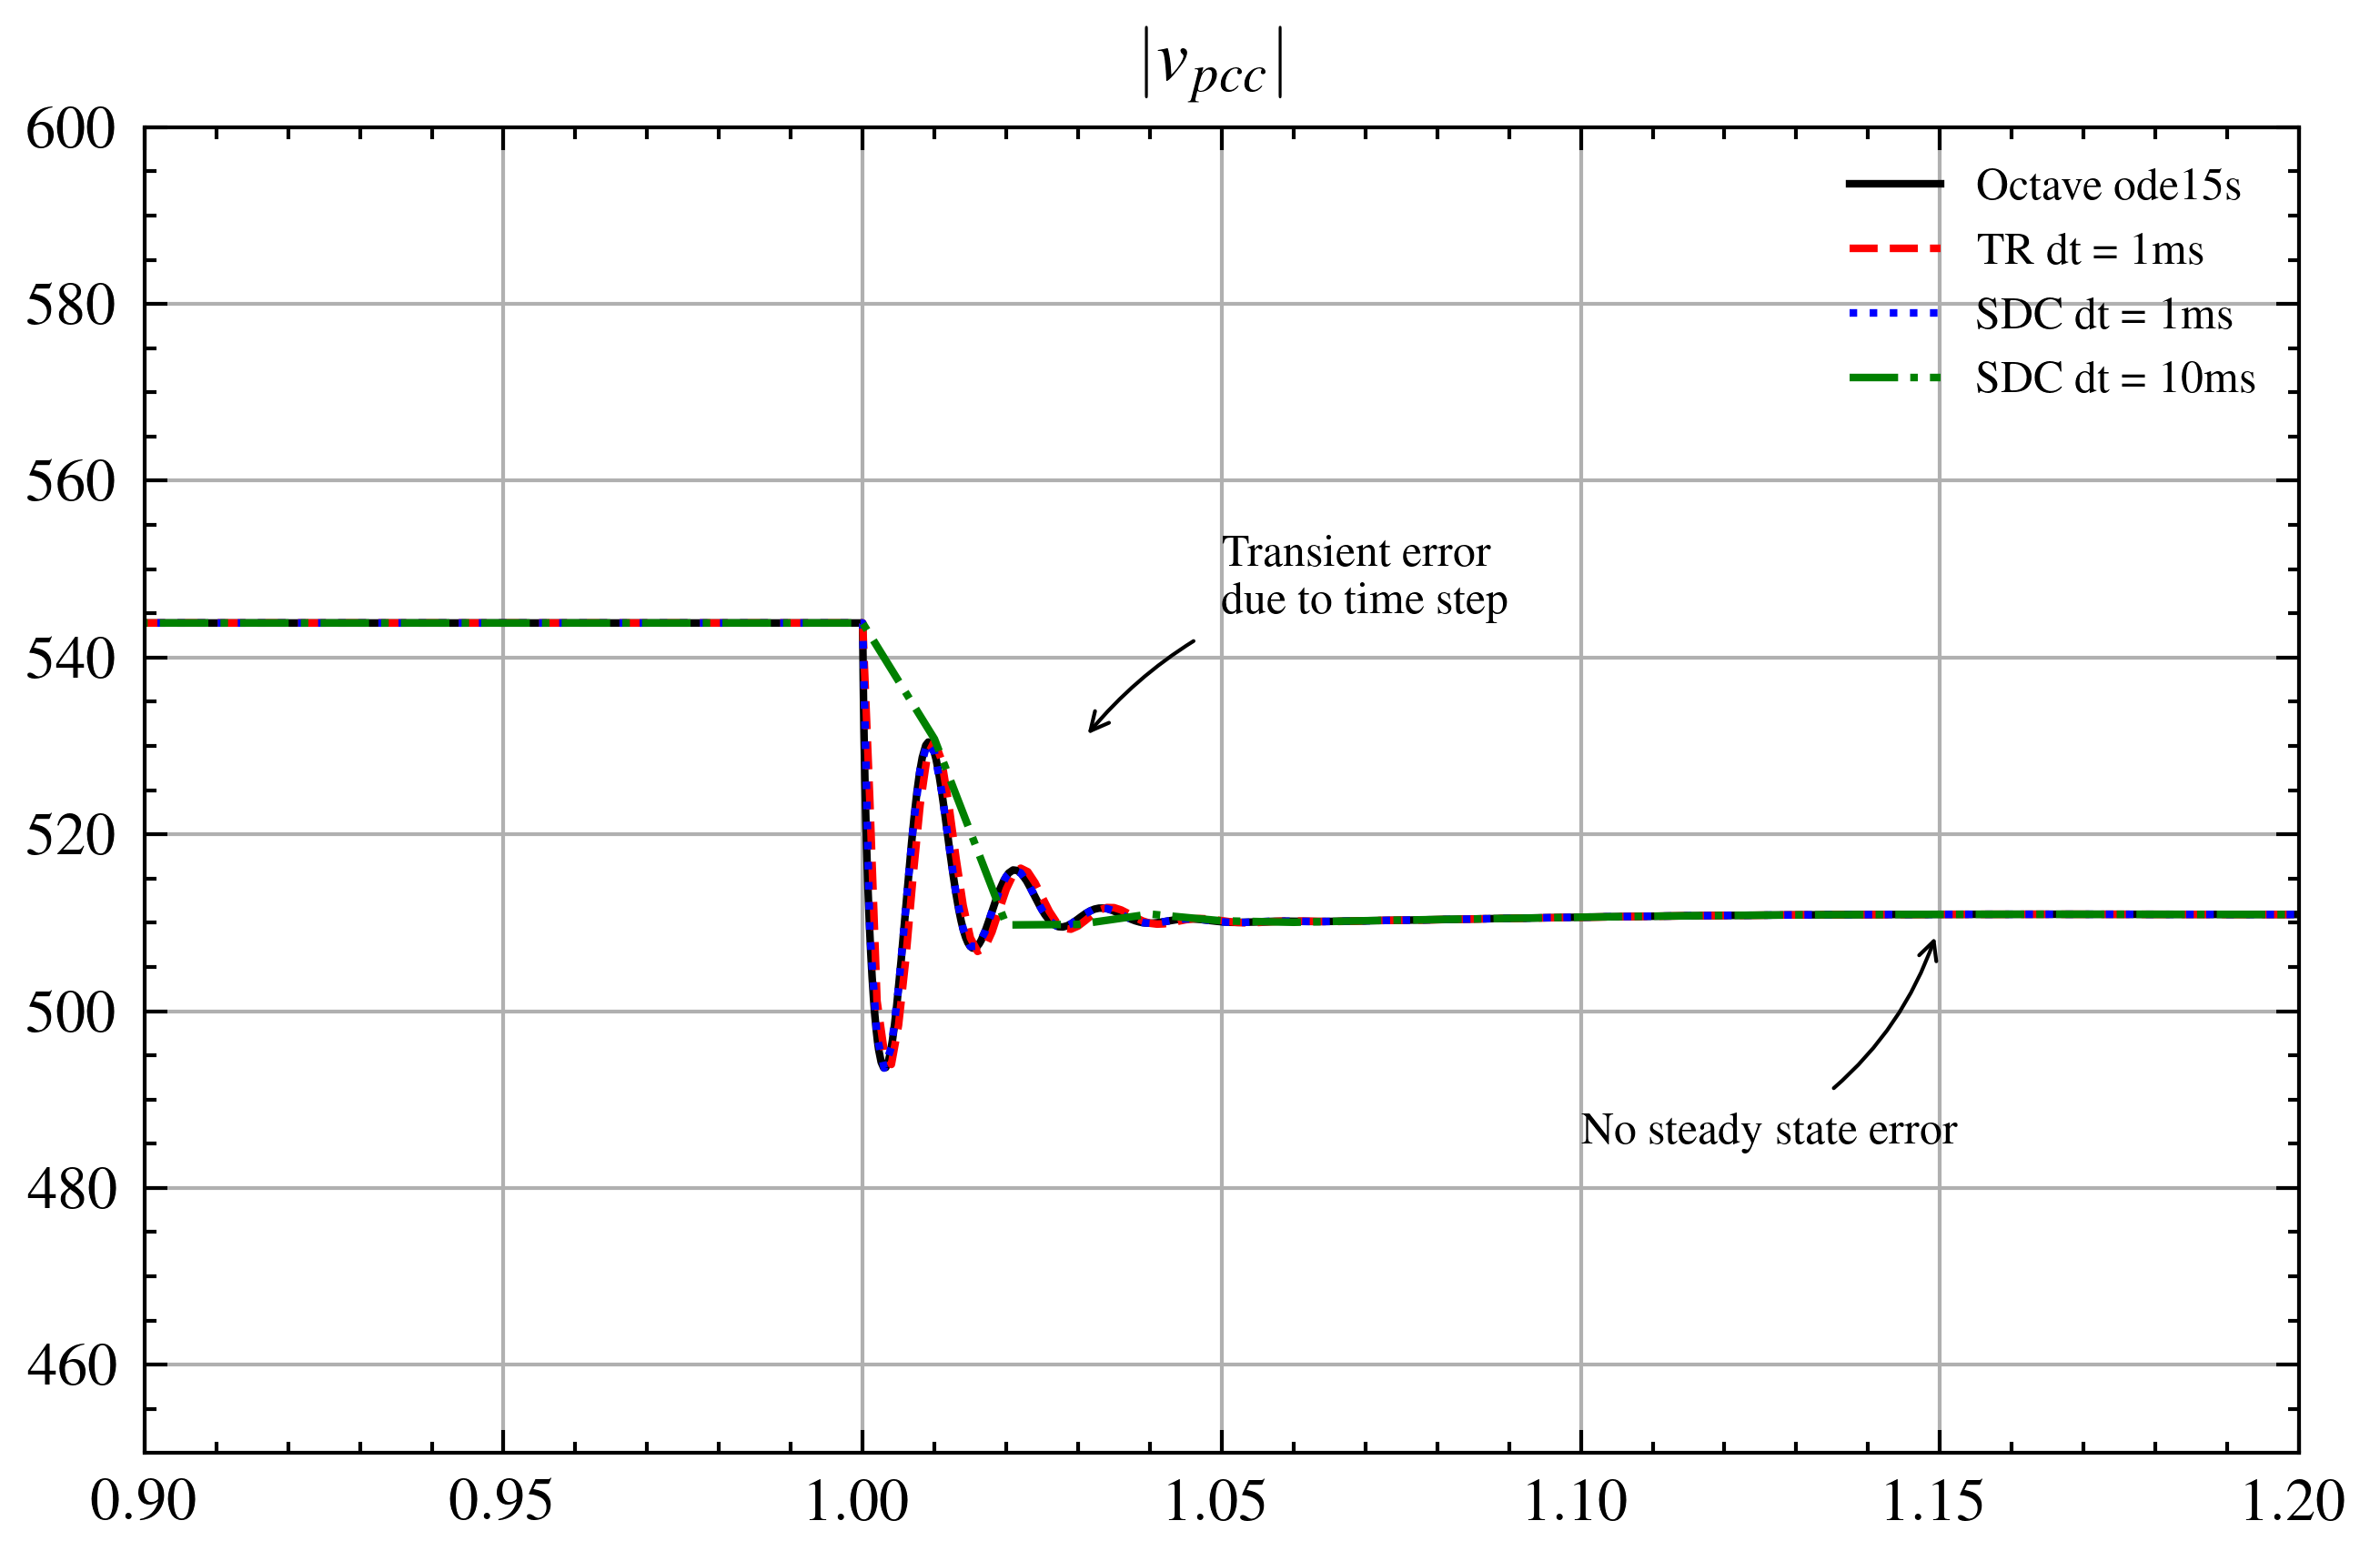

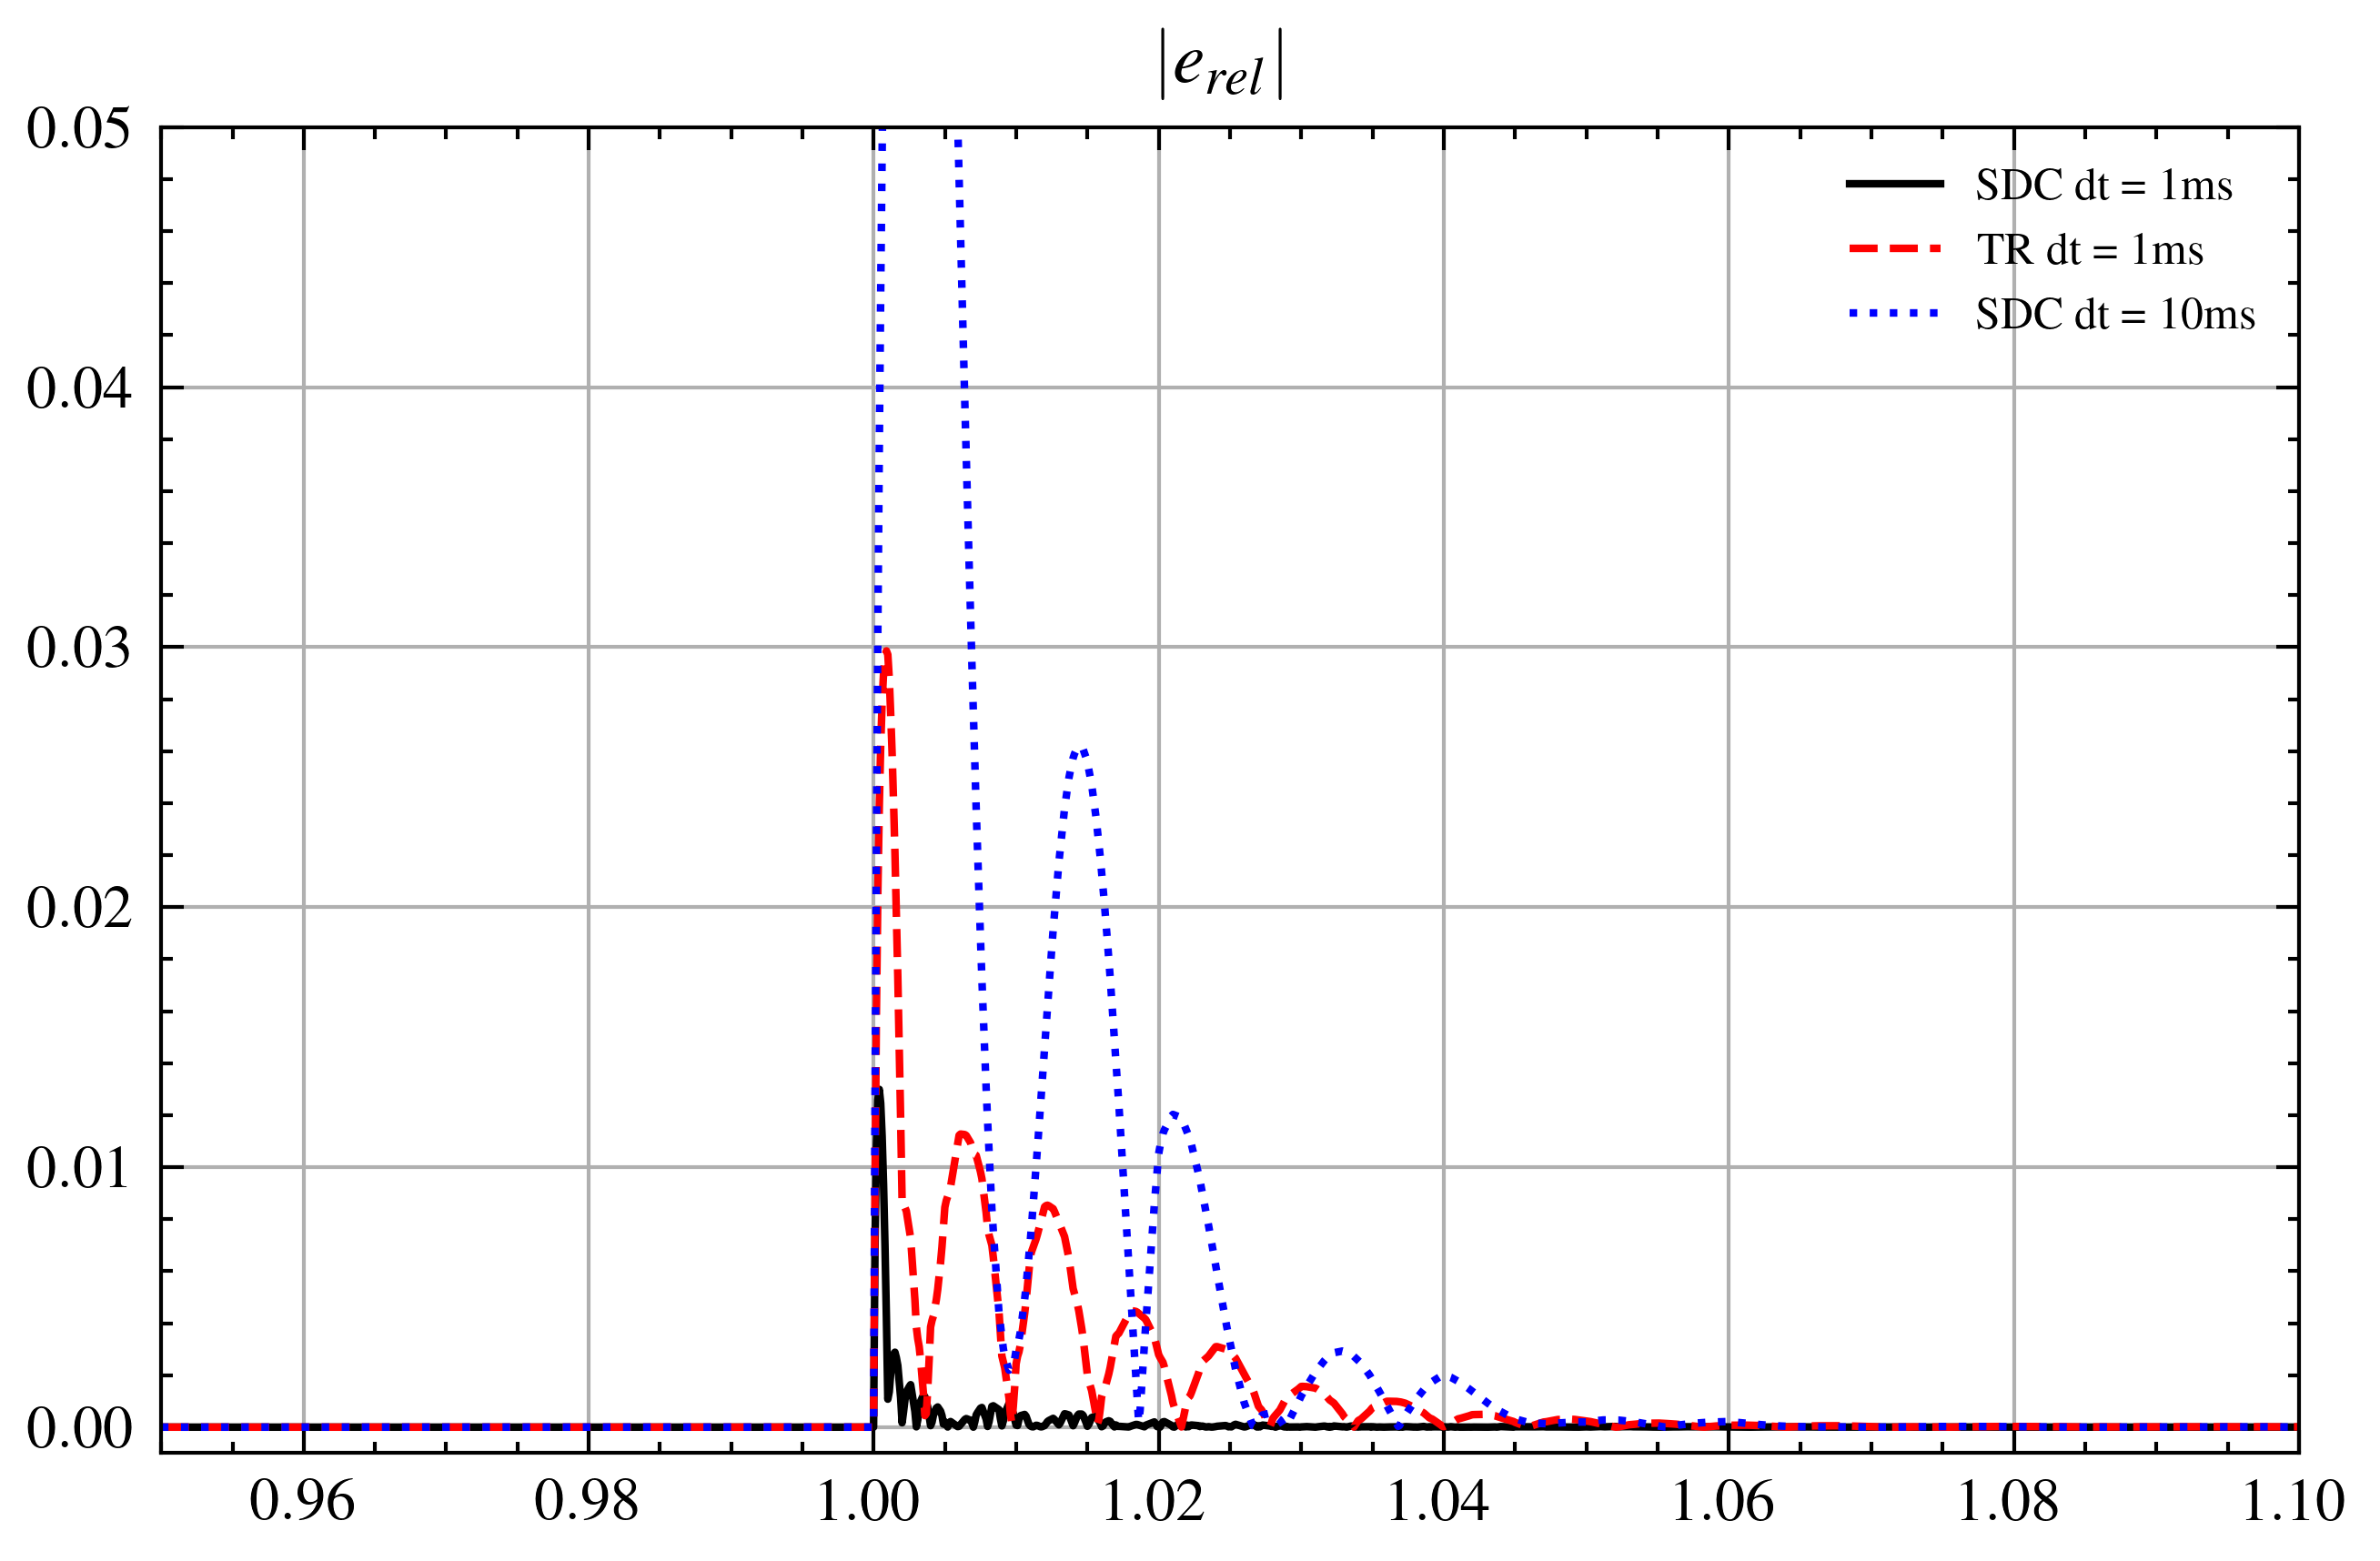

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 3))
# ax.plot(t_ref, rel_error_ode15s, label='ode15s')
ax.plot(t_ref, rel_error_sdc_1ms_shifted, label='SDC dt = 1ms')
ax.plot(t_ref, rel_error_TR_1ms, label='TR dt = 1ms')
ax.plot(t_ref, rel_error_sdc_10ms_shifted, label='SDC dt = 10ms')
# ax.plot(t_ref, rel_error_sdc_10ms, label='SDC dt = 10ms ')

ax.legend(loc='best', fontsize=6)
ax.set_title('$|e_{rel}|$')
ax.set_ylim(-1e-3, 0.05)
ax.set_xlim(0.95, 1.1)
ax.grid(True)
plt.tight_layout()
# plt.show()
plt_helper.plt.savefig('fig/error_v_pcc_compare.pdf', dpi=300)



In [ ]:


# # ---------------------------
# # 3. Plotting: Four subplots in one figure
# # ---------------------------
# fig, axs = plt.subplots(2, 2, figsize=(6, 5))

# # Subplot 1: Speedup vs restol
# axs[0, 0].plot(df_restol['restol'], df_restol['speedup'], marker='o')
# axs[0, 0].set_xscale('log')
# axs[0, 0].set_xlabel('Residual Tolerance (restol)')
# axs[0, 0].set_ylabel('Speedup (w.r.t. lowest restol)')
# axs[0, 0].set_title('Speedup with varying residual tolerance \n (with nttol = 1e-10)')

# # Subplot 2: Speedup vs nttol (for fixed restol = 0.01)
# axs[0, 1].plot(df_nttol['nttol'], df_nttol['speedup'], marker='o')
# axs[0, 1].set_xscale('log')
# axs[0, 1].set_xlabel('Newton Tolerance (nttol)')
# axs[0, 1].set_ylabel('Speedup (w.r.t. lowest nttol)')
# axs[0, 1].set_title('Speedup with varying Newton tolerance \n  (with restol=0.01)')

# # Subplot 3: Accuracy (RMSE error) and speedup vs nttol (restol fixed at 0.01)
# ax1 = axs[1, 0]
# restol_keys = sorted(errors_restol.keys())
# error_vals_restol = [errors_restol[k] for k in restol_keys]
# ax1.plot(restol_keys, error_vals_restol, marker='o', color='blue', label='Error (RMSE)')
# ax1.set_xscale('log')
# ax1.set_xlabel('restol')
# ax1.set_ylabel('Error (RMSE)', color='blue')
# ax1.tick_params(axis='y', labelcolor='blue')
# ax1.set_title('Accuracy vs restol \n(nttol=1e-10)')

# # Twin axis for speedup data using restol timing data
# # restol_speedup = [df_restol.loc[df_restol['restol'] == tol, 'speedup'].iloc[0] for tol in restol_keys]
# # ax2b = ax2.twinx()
# # ax2b.plot(restol_keys, restol_speedup, marker='s', color='red', label='Speedup')
# # ax2b.set_ylabel('Speedup', color='red')
# # ax2b.tick_params(axis='y', labelcolor='red')


# # Subplot 4: Accuracy (RMSE error) and speedup vs restol (nttol fixed at 1e-10)
# ax2 = axs[1, 1]

# nttol_keys = sorted(errors_nttol.keys())
# error_vals = [errors_nttol[k] for k in nttol_keys]
# ax2.plot(nttol_keys, error_vals, marker='o', color='blue', label='Error (RMSE)')
# ax2.set_xscale('log')
# ax2.set_xlabel('nttol')
# ax2.set_ylabel('Error (RMSE)', color='blue')
# ax2.tick_params(axis='y', labelcolor='blue')
# ax2.set_title('Accuracy vs nttol \n(restol=0.01)')

# # Twin axis for speedup data
# # ax1b = ax1.twinx()
# # # Make sure nttol keys in df_nttol are sorted similarly
# # nttol_speedup = [df_nttol.loc[df_nttol['nttol'] == tol, 'speedup'].iloc[0] for tol in nttol_keys]
# # ax1b.plot(nttol_keys, nttol_speedup, marker='s', color='red', label='Speedup')
# # ax1b.set_ylabel('Speedup', color='red')
# # ax1b.tick_params(axis='y', labelcolor='red')
# plt.tight_layout()
# plt.show()
